# 🚗 Prediksi Kepadatan Parkir — Enhanced
### Alur: EDA → Feature Engineering → Clustering → Klasifikasi → Export Model

---
```
Dataset
  │
  ▼
[TAHAP 1] Preprocessing & EDA mendalam
          → Distribusi, korelasi, time-series analysis
  │
  ▼
[TAHAP 2] Feature Engineering Lanjutan
          → Lag features, rolling stats, interaction features
          → Cyclical encoding, capacity ratio, crowd index
  │
  ▼
[TAHAP 3] K-Means Clustering (Lat & Long)
          → Elbow Method → Zona Geografis
  │
  ▼
[TAHAP 4] Labeling: Sepi / Sedang / Padat
  │
  ▼
[TAHAP 5] Klasifikasi (SVM, XGBoost, Ridge, Naive Bayes, KNN)
          → Time-based split → CV → Hyperparameter tuning
  │
  ▼
[TAHAP 6] Evaluasi & Analisis Mendalam
  │
  ▼
[TAHAP 7] Export Model → Streamlit
```


## 1. Install & Import Library

In [ ]:
!pip install -q xgboost scikit-learn pandas numpy matplotlib seaborn joblib

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings, joblib, os
warnings.filterwarnings('ignore')

# Clustering
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import TimeSeriesSplit, cross_val_score

# Klasifikasi
from sklearn.svm import SVC, SVR
from sklearn.linear_model import RidgeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, classification_report,
    confusion_matrix, ConfusionMatrixDisplay
)

print('Semua library berhasil diimport')

Semua library berhasil diimport


## 2. Load Dataset

In [3]:
df_raw = pd.read_csv("parkingStream.csv")
print(f'Shape    : {df_raw.shape}')
print(f'Kolom    : {list(df_raw.columns)}')
df_raw.head()

Shape    : (18368, 11)
Kolom    : ['ID', 'SystemCodeNumber', 'Capacity', 'Latitude', 'Longitude', 'Occupancy', 'VehicleType', 'TrafficConditionNearby', 'QueueLength', 'IsSpecialDay', 'Timestamp']


,ID,SystemCodeNumber,Capacity,Latitude,Longitude,Occupancy,VehicleType,TrafficConditionNearby,QueueLength,IsSpecialDay,Timestamp
0,0,BHMBCCMKT01,577,26.144536,91.736172,61,car,low,1,0,2016-10-04 07:59:00
1,5248,BHMNCPHST01,1200,26.140014,91.731000,237,bike,low,2,0,2016-10-04 07:59:00
2,3936,BHMMBMMBX01,687,20.000035,78.000003,264,car,low,2,0,2016-10-04 07:59:00
3,6560,BHMNCPNST01,485,26.140048,91.730972,249,car,low,2,0,2016-10-04 07:59:00
4,17056,Shopping,1920,26.150504,91.733531,614,cycle,low,2,0,2016-10-04 07:59:00


## 3. Preprocessing

In [4]:
df = df_raw.copy()

# SEBELUM PREPROCESSING
# ==============================
before_rows = len(df)
before_dup  = df.duplicated().sum()
before_nan  = df[['Capacity','Occupancy','QueueLength','Latitude','Longitude']].isnull().sum().sum()
before_neg  = ((df['Capacity'] <= 0) | (df['Occupancy'] < 0) | (df['QueueLength'] < 0)).sum()
before_clip = (df['Occupancy'] > df['Capacity']).sum()

# --- Hapus duplikat ---
df = df.drop_duplicates()

# --- Konversi tipe numerik ---
for col in ['Capacity', 'Occupancy', 'QueueLength', 'Latitude', 'Longitude']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# --- Buang NaN dan nilai negatif ---
df = df.dropna(subset=['Capacity', 'Occupancy', 'QueueLength', 'Latitude', 'Longitude'])
df = df[(df['Capacity'] > 0) & (df['Occupancy'] >= 0) & (df['QueueLength'] >= 0)]

# --- Clip Occupancy agar tidak melebihi Capacity ---
df['Occupancy'] = np.minimum(df['Occupancy'], df['Capacity'])

# --- Hitung Occupancy Rate ---
df['OccupancyRate'] = df['Occupancy'] / df['Capacity']

# SESUDAH PREPROCESSING
# ==============================
after_rows = len(df)
after_dup  = df.duplicated().sum()
after_nan  = df[['Capacity','Occupancy','QueueLength','Latitude','Longitude']].isnull().sum().sum()
after_neg  = ((df['Capacity'] <= 0) | (df['Occupancy'] < 0) | (df['QueueLength'] < 0)).sum()
after_clip = (df['Occupancy'] > df['Capacity']).sum()

# --- Parse Timestamp & urutkan (penting untuk time-based split) ---
df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
df = df.dropna(subset=['Timestamp'])
df = df.sort_values('Timestamp').reset_index(drop=True)

# --- Feature Engineering Waktu ---
df['hour']         = df['Timestamp'].dt.hour
df['dayofweek']    = df['Timestamp'].dt.dayofweek
df['month']        = df['Timestamp'].dt.month
df['is_weekend']   = (df['dayofweek'] >= 5).astype(int)
df['hour_sin']     = np.sin(2 * np.pi * df['hour'] / 24)
df['hour_cos']     = np.cos(2 * np.pi * df['hour'] / 24)
df['is_rush_hour'] = df['hour'].isin([7,8,9,16,17,18,19]).astype(int)

# --- Kolom kategori → string ---
for c in ['SystemCodeNumber', 'VehicleType', 'TrafficConditionNearby', 'IsSpecialDay']:
    df[c] = df[c].astype(str)

# --- Gabungkan kategori jarang → Other ---
def group_rare(series, min_count=200):
    vc = series.value_counts()
    keep = vc[vc >= min_count].index
    return series.where(series.isin(keep), other='Other')

df['SystemCodeNumber']       = group_rare(df['SystemCodeNumber'])
df['VehicleType']            = group_rare(df['VehicleType'])
df['TrafficConditionNearby'] = group_rare(df['TrafficConditionNearby'])

print(f'Shape setelah preprocessing : {df.shape}')
print(f'Rentang waktu               : {df["Timestamp"].min()} → {df["Timestamp"].max()}')
df.head(3)

Shape setelah preprocessing : (18368, 19)
Rentang waktu               : 2016-10-04 07:59:00 → 2016-12-19 16:30:00


,ID,SystemCodeNumber,Capacity,Latitude,Longitude,Occupancy,VehicleType,TrafficConditionNearby,QueueLength,IsSpecialDay,Timestamp,OccupancyRate,hour,dayofweek,month,is_weekend,hour_sin,hour_cos,is_rush_hour
0,0,BHMBCCMKT01,577,26.144536,91.736172,61,car,low,1,0,2016-10-04 07:59:00,0.105719,7,1,10,0,0.965926,-0.258819,1
1,15744,Others-CCCPS98,3103,26.147500,91.727978,588,car,average,2,0,2016-10-04 07:59:00,0.189494,7,1,10,0,0.965926,-0.258819,1
2,13120,Others-CCCPS202,2937,26.147491,91.727997,547,bike,low,2,0,2016-10-04 07:59:00,0.186244,7,1,10,0,0.965926,-0.258819,1


In [5]:
summary = pd.DataFrame({
    'Kondisi'               : ['Jumlah Baris', 'Duplikat', 'NaN Numerik', 'Nilai Negatif/Nol', 'Occupancy > Capacity'],
    'Sebelum'               : [before_rows, before_dup, before_nan, before_neg, before_clip],
    'Sesudah'               : [after_rows,  after_dup,  after_nan,  after_neg,  after_clip],
})

summary['Perubahan'] = summary['Sebelum'] - summary['Sesudah']
summary['Status']    = summary['Perubahan'].apply(
    lambda x: ' Bersih' if x == 0 and summary.loc[summary['Perubahan']==x].index[0] != 0
              else (' Ditangani' if x > 0 else ('➕ Bertambah' if x < 0 else ' Tidak Ada Masalah'))
)

# Baris khusus untuk Jumlah Baris (perubahan = pengurangan baris)
summary.loc[summary['Kondisi'] == 'Jumlah Baris', 'Status'] = (
    ' Sama' if summary.loc[summary['Kondisi']=='Jumlah Baris','Perubahan'].values[0] == 0
    else f"🗑️ -{summary.loc[summary['Kondisi']=='Jumlah Baris','Perubahan'].values[0]} baris"
)

print("       RINGKASAN PREPROCESSING: BEFORE vs AFTER")
print("=" * 55)
print(summary.to_string(index=False))

       RINGKASAN PREPROCESSING: BEFORE vs AFTER
             Kondisi  Sebelum  Sesudah  Perubahan             Status
        Jumlah Baris    18368    18368          0               Sama
            Duplikat        0        0          0  Tidak Ada Masalah
         NaN Numerik        0        0          0  Tidak Ada Masalah
   Nilai Negatif/Nol        0        0          0  Tidak Ada Masalah
Occupancy > Capacity      241        0        241          Ditangani


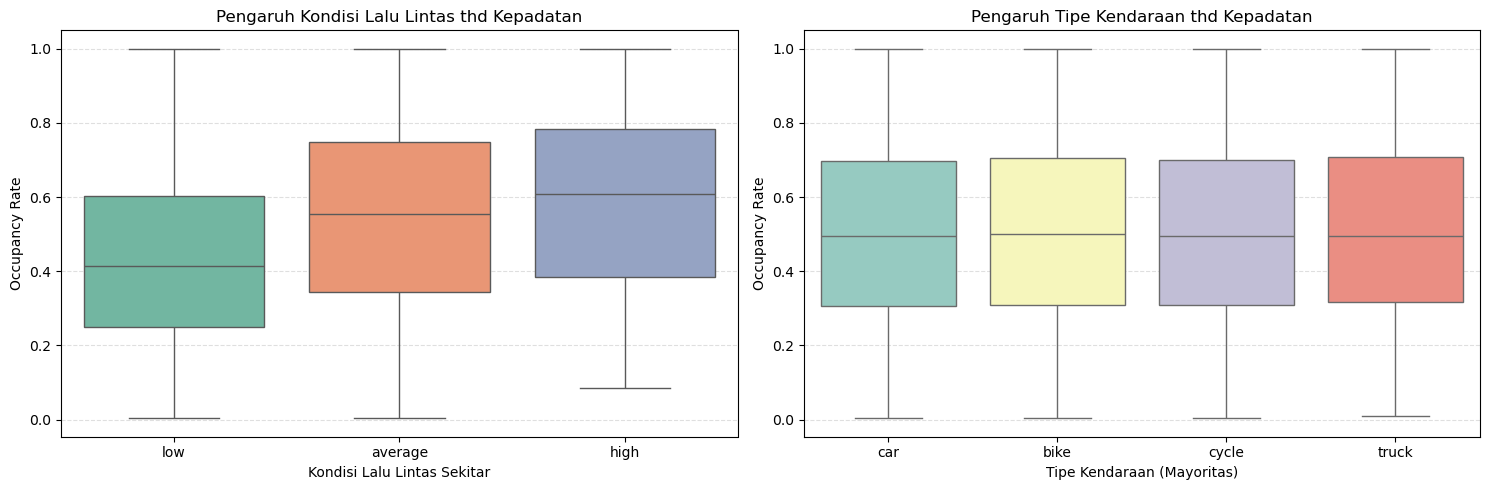

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Plot 1: Pengaruh Kondisi Lalu Lintas terhadap Kepadatan
sns.boxplot(data=df, x='TrafficConditionNearby', y='OccupancyRate', palette='Set2', ax=axes[0])
axes[0].set_title('Pengaruh Kondisi Lalu Lintas thd Kepadatan', fontsize=12)
axes[0].set_xlabel('Kondisi Lalu Lintas Sekitar')
axes[0].set_ylabel('Occupancy Rate')
axes[0].grid(True, linestyle='--', alpha=0.4, axis='y')

# Plot 2: Pengaruh Tipe Kendaraan terhadap Kepadatan
sns.boxplot(data=df, x='VehicleType', y='OccupancyRate', palette='Set3', ax=axes[1])
axes[1].set_title('Pengaruh Tipe Kendaraan thd Kepadatan', fontsize=12)
axes[1].set_xlabel('Tipe Kendaraan (Mayoritas)')
axes[1].set_ylabel('Occupancy Rate')
axes[1].grid(True, linestyle='--', alpha=0.4, axis='y')

plt.tight_layout()
plt.show()

## 3b. Exploratory Data Analysis (EDA) Mendalam

> Sebelum masuk ke clustering & klasifikasi, kita analisis distribusi data secara menyeluruh untuk mendapatkan insight awal.


STATISTIK DESKRIPTIF


,Capacity,Occupancy,QueueLength,OccupancyRate
count,18368.000,18368.000,18368.000,18368.000
mean,1605.214,730.947,4.588,0.509
std,1131.154,621.240,2.580,0.245
min,387.000,2.000,0.000,0.003
25%,577.000,322.000,2.000,0.307
50%,1261.000,568.000,4.000,0.496
75%,2803.000,976.000,6.000,0.701
max,3883.000,3499.000,15.000,1.000


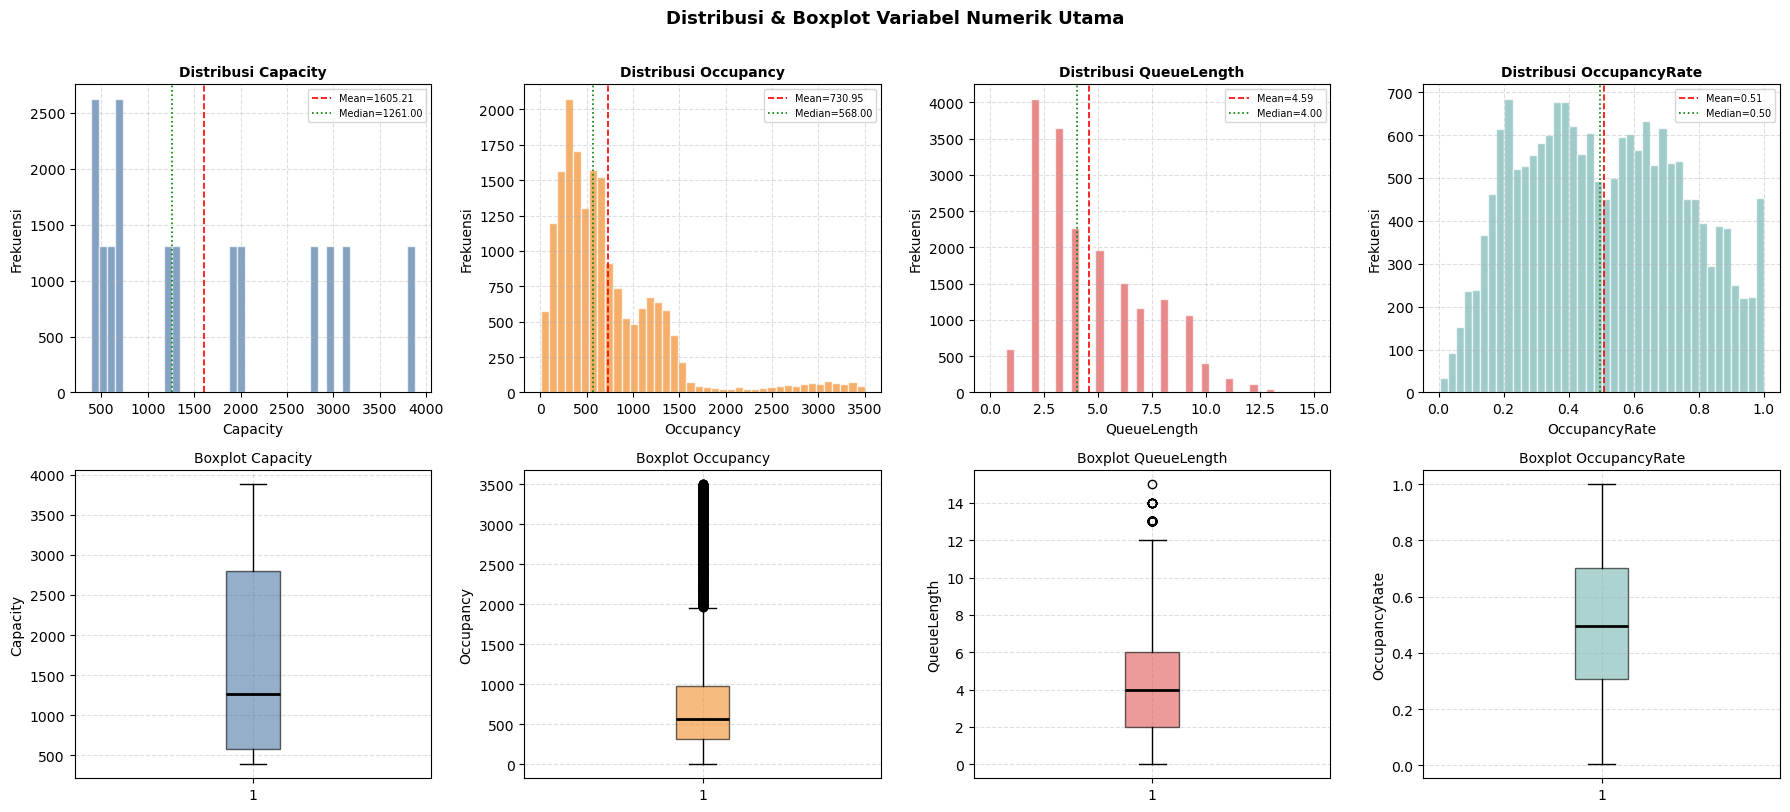


INSIGHT:
  • OccupancyRate skewness = 0.132  ( distribusi relatif simetris)
  • Rata-rata Occupancy Rate: 0.509
  • Proporsi lokasi sangat padat (OccupancyRate > 0.9): 6.3%
  • Proporsi lokasi sepi (OccupancyRate < 0.3)        : 24.1%


In [7]:
# ─── EDA 1: Overview statistik deskriptif ───────────────────────────────────
print('='*65)
print('STATISTIK DESKRIPTIF')
print('='*65)
display(df[['Capacity','Occupancy','QueueLength','OccupancyRate']].describe().round(3))

# Distribusi numerik utama
num_viz = ['Capacity', 'Occupancy', 'QueueLength', 'OccupancyRate']
fig, axes = plt.subplots(2, 4, figsize=(18, 8))

colors = ['#4e79a7', '#f28e2b', '#e15759', '#76b7b2']
for i, (col, color) in enumerate(zip(num_viz, colors)):
    ax_hist = axes[0, i]
    ax_box  = axes[1, i]

    # Histogram + KDE
    ax_hist.hist(df[col].dropna(), bins=40, color=color, alpha=0.7, edgecolor='white')
    ax_hist.set_title(f'Distribusi {col}', fontsize=10, fontweight='bold')
    ax_hist.set_xlabel(col)
    ax_hist.set_ylabel('Frekuensi')
    ax_hist.grid(True, linestyle='--', alpha=0.4)

    # Statistik di dalam plot
    mu = df[col].mean()
    med = df[col].median()
    ax_hist.axvline(mu, color='red', linestyle='--', linewidth=1.2, label=f'Mean={mu:.2f}')
    ax_hist.axvline(med, color='green', linestyle=':', linewidth=1.2, label=f'Median={med:.2f}')
    ax_hist.legend(fontsize=7)

    # Box plot
    ax_box.boxplot(df[col].dropna(), patch_artist=True,
                   boxprops=dict(facecolor=color, alpha=0.6),
                   medianprops=dict(color='black', linewidth=2))
    ax_box.set_title(f'Boxplot {col}', fontsize=10)
    ax_box.set_ylabel(col)
    ax_box.grid(True, linestyle='--', alpha=0.4)

plt.suptitle('Distribusi & Boxplot Variabel Numerik Utama', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

# ─── Insight ─────────────────────────────────────────────────────────────────
print('\nINSIGHT:')
skew_rate = df['OccupancyRate'].skew()
print(f'  • OccupancyRate skewness = {skew_rate:.3f}  (',
      'positif/miring kanan → banyak data OccupancyRate rendah)' if skew_rate > 0.5
      else 'distribusi relatif simetris)' if abs(skew_rate) <= 0.5
      else 'negatif/miring kiri → banyak data OccupancyRate tinggi)')
print(f'  • Rata-rata Occupancy Rate: {df["OccupancyRate"].mean():.3f}')
print(f'  • Proporsi lokasi sangat padat (OccupancyRate > 0.9): {(df["OccupancyRate"] > 0.9).mean()*100:.1f}%')
print(f'  • Proporsi lokasi sepi (OccupancyRate < 0.3)        : {(df["OccupancyRate"] < 0.3).mean()*100:.1f}%')


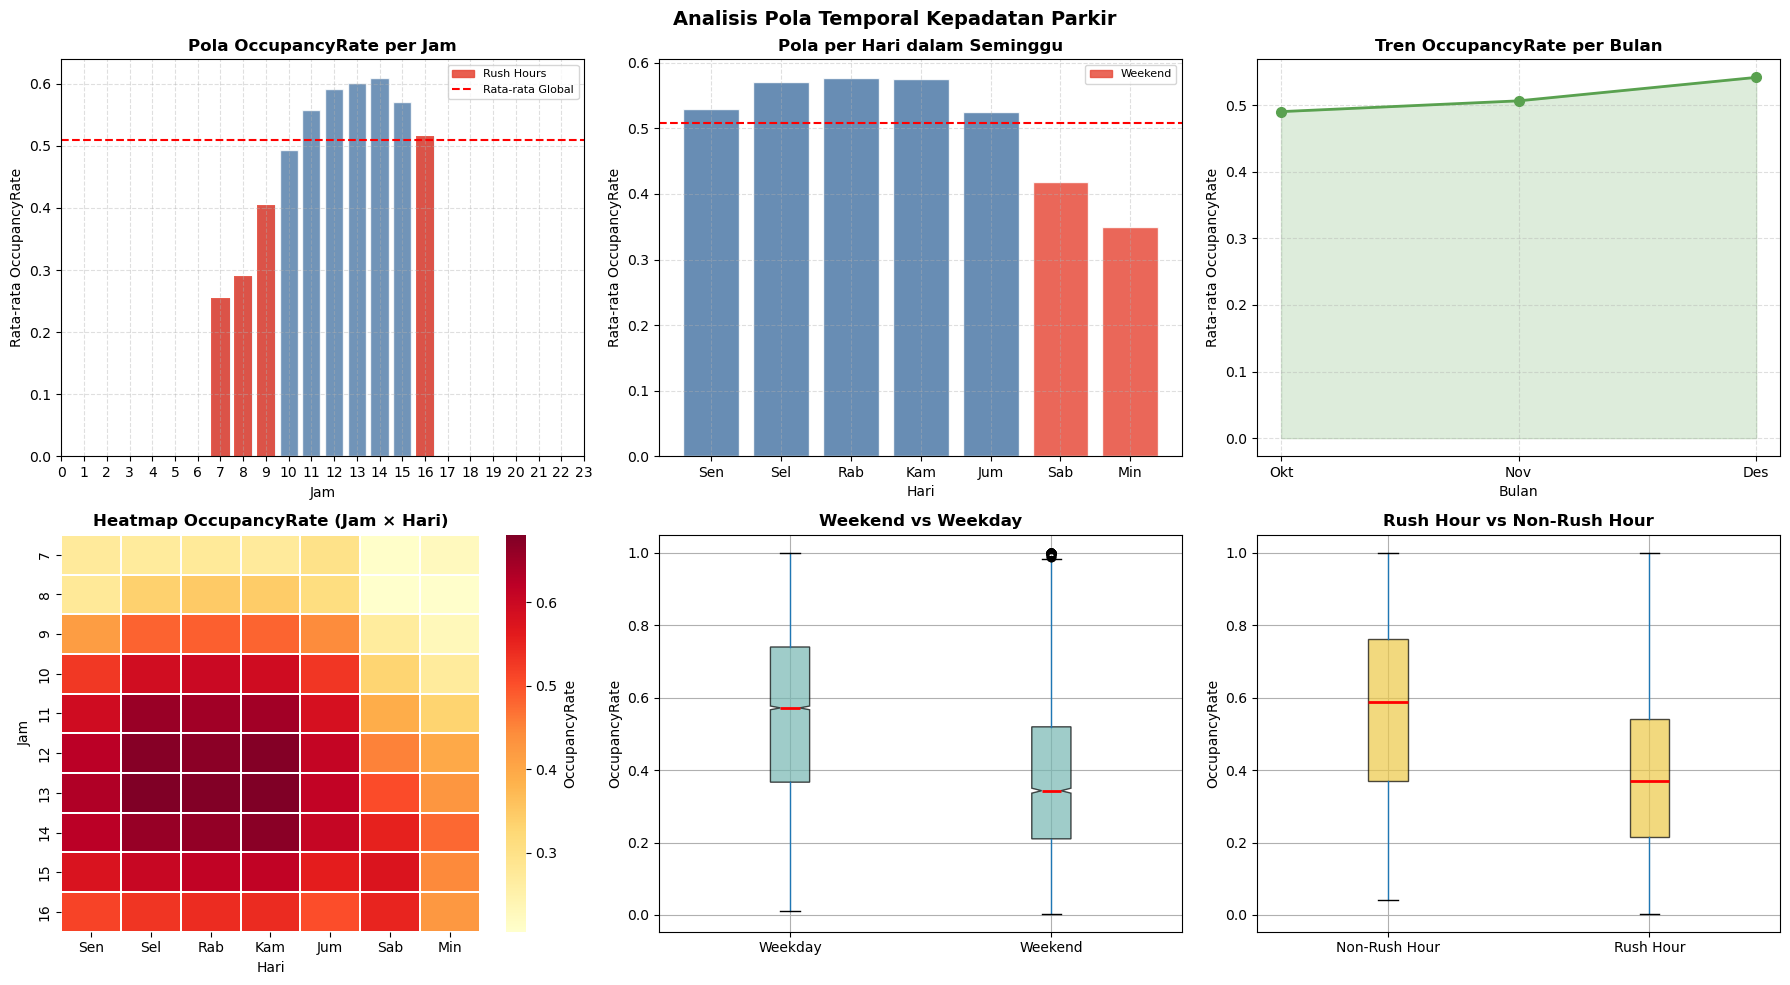


INSIGHT TEMPORAL:
  • Jam tersibuk   : 14:00 (OccupancyRate rata-rata: 0.609)
  • Jam paling sepi: 07:00 (OccupancyRate rata-rata : 0.254)
  • Hari tersibuk  : Rabu
  • Weekend vs Weekday: 0.385 vs 0.556  (selisih 0.171)
  • Rush Hour vs Non-Rush: 0.386 vs 0.571  (selisih 0.186)


In [8]:
# ─── EDA 2: Pola Temporal ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# 2a. Rata-rata OccupancyRate per jam
hour_agg = df.groupby('hour')['OccupancyRate'].mean()
ax = axes[0, 0]
bars = ax.bar(hour_agg.index, hour_agg.values, color='#4e79a7', alpha=0.8, edgecolor='white')
ax.set_xlabel('Jam')
ax.set_ylabel('Rata-rata OccupancyRate')
ax.set_title('Pola OccupancyRate per Jam', fontweight='bold')
ax.axhline(df['OccupancyRate'].mean(), color='red', linestyle='--', linewidth=1.5, label='Rata-rata Global')
rush_hours = [7,8,9,16,17,18,19]
for h in rush_hours:
    if h in hour_agg.index:
        ax.bar(h, hour_agg[h], color='#e74c3c', alpha=0.9)
rush_patch = mpatches.Patch(color='#e74c3c', alpha=0.9, label='Rush Hours')
ax.legend(handles=[rush_patch, plt.Line2D([0],[0],color='red',linestyle='--',label='Rata-rata Global')], fontsize=8)
ax.set_xticks(range(0, 24))
ax.grid(True, linestyle='--', alpha=0.4)

# 2b. OccupancyRate per hari dalam minggu
dow_agg = df.groupby('dayofweek')['OccupancyRate'].mean()
day_labels_short = {0:'Sen',1:'Sel',2:'Rab',3:'Kam',4:'Jum',5:'Sab',6:'Min'}
available_dow_labels = [day_labels_short[d] for d in dow_agg.index]
colors_dow = ['#e74c3c' if d >= 5 else '#4e79a7' for d in dow_agg.index]
ax = axes[0, 1]
ax.bar(available_dow_labels, dow_agg.values, color=colors_dow, alpha=0.85, edgecolor='white')
ax.set_xlabel('Hari')
ax.set_ylabel('Rata-rata OccupancyRate')
ax.set_title('Pola per Hari dalam Seminggu', fontweight='bold')
ax.axhline(df['OccupancyRate'].mean(), color='red', linestyle='--', linewidth=1.5)
weekend_patch = mpatches.Patch(color='#e74c3c', alpha=0.85, label='Weekend')
ax.legend(handles=[weekend_patch], fontsize=8)
ax.grid(True, linestyle='--', alpha=0.4)

# 2c. OccupancyRate per bulan
month_agg = df.groupby('month')['OccupancyRate'].mean()
month_labels = ['Jan','Feb','Mar','Apr','Mei','Jun','Jul','Agu','Sep','Okt','Nov','Des']
ax = axes[0, 2]
available_months = [month_labels[m-1] for m in month_agg.index]
ax.plot(available_months, month_agg.values, 'o-', color='#59a14f', linewidth=2, markersize=7)
ax.fill_between(available_months, month_agg.values, alpha=0.2, color='#59a14f')
ax.set_xlabel('Bulan')
ax.set_ylabel('Rata-rata OccupancyRate')
ax.set_title('Tren OccupancyRate per Bulan', fontweight='bold')
ax.grid(True, linestyle='--', alpha=0.4)

# 2d. Heatmap jam vs hari
pivot_heatmap = df.pivot_table(values='OccupancyRate', index='hour', columns='dayofweek', aggfunc='mean')
pivot_heatmap = pivot_heatmap.rename(columns=day_labels_short)
ax = axes[1, 0]
sns.heatmap(pivot_heatmap, ax=ax, cmap='YlOrRd', annot=False, fmt='.2f',
            linewidths=0.3, cbar_kws={'label': 'OccupancyRate'})
ax.set_title('Heatmap OccupancyRate (Jam × Hari)', fontweight='bold')
ax.set_xlabel('Hari')
ax.set_ylabel('Jam')

# 2e. Weekend vs Weekday
ax = axes[1, 1]
df.boxplot(column='OccupancyRate', by='is_weekend', ax=ax,
           patch_artist=True, notch=True,
           boxprops=dict(facecolor='#76b7b2', alpha=0.7),
           medianprops=dict(color='red', linewidth=2))
unique_is_weekend = sorted(df['is_weekend'].unique())
labels_weekend = ['Weekday' if val == 0 else 'Weekend' for val in unique_is_weekend]
ax.set_xticklabels(labels_weekend)
ax.set_title('Weekend vs Weekday', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('OccupancyRate')
plt.sca(ax)
plt.title('Weekend vs Weekday', fontweight='bold')

# 2f. Rush hour vs non-rush
ax = axes[1, 2]
df.boxplot(column='OccupancyRate', by='is_rush_hour', ax=ax,
           patch_artist=True,
           boxprops=dict(facecolor='#edc948', alpha=0.7),
           medianprops=dict(color='red', linewidth=2))
unique_is_rush = sorted(df['is_rush_hour'].unique())
labels_rush = ['Non-Rush Hour' if val == 0 else 'Rush Hour' for val in unique_is_rush]
ax.set_xticklabels(labels_rush)
ax.set_title('Rush Hour vs Non-Rush Hour', fontweight='bold')
ax.set_xlabel('')
ax.set_ylabel('OccupancyRate')
plt.sca(ax)
plt.title('Rush Hour vs Non-Rush Hour', fontweight='bold')

plt.suptitle('Analisis Pola Temporal Kepadatan Parkir', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nINSIGHT TEMPORAL:')
peak_hour = hour_agg.idxmax() if not hour_agg.empty else None
low_hour  = hour_agg.idxmin() if not hour_agg.empty else None
peak_day  = dow_agg.idxmax() if not dow_agg.empty else None
day_names = {0:'Senin',1:'Selasa',2:'Rabu',3:'Kamis',4:'Jumat',5:'Sabtu',6:'Minggu'}

if peak_hour is not None:
    print(f'  • Jam tersibuk   : {peak_hour:02d}:00 (OccupancyRate rata-rata: {hour_agg[peak_hour]:.3f})')
if low_hour is not None:
    print(f'  • Jam paling sepi: {low_hour:02d}:00 (OccupancyRate rata-rata : {hour_agg[low_hour]:.3f})')
if peak_day is not None:
    print(f'  • Hari tersibuk  : {day_names.get(peak_day, peak_day)}')

wkd_df = df[df['is_weekend']==1]
wkd = wkd_df['OccupancyRate'].mean() if not wkd_df.empty else 0.0
wkn_df = df[df['is_weekend']==0]
wkn = wkn_df['OccupancyRate'].mean() if not wkn_df.empty else 0.0

rush_on_df = df[df['is_rush_hour']==1]
rush_on  = rush_on_df['OccupancyRate'].mean() if not rush_on_df.empty else 0.0
rush_off_df = df[df['is_rush_hour']==0]
rush_off = rush_off_df['OccupancyRate'].mean() if not rush_off_df.empty else 0.0

print(f'  • Weekend vs Weekday: {wkd:.3f} vs {wkn:.3f}  (selisih {abs(wkd-wkn):.3f})')
print(f'  • Rush Hour vs Non-Rush: {rush_on:.3f} vs {rush_off:.3f}  (selisih {abs(rush_on-rush_off):.3f})')


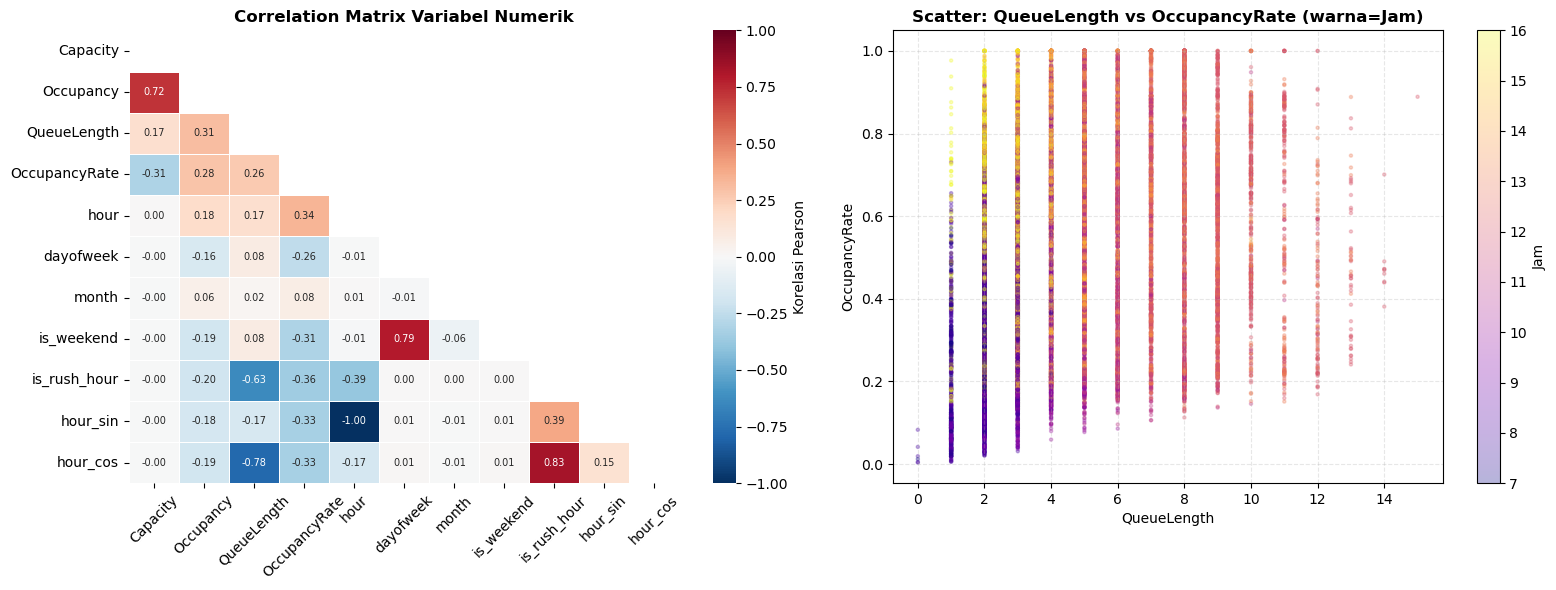


KORELASI TERHADAP OccupancyRate:
  is_rush_hour         -███████ -0.357
  hour                 +██████ +0.337
  hour_cos             -██████ -0.332
  hour_sin             -██████ -0.332
  is_weekend           -██████ -0.311
  Capacity             -██████ -0.309
  Occupancy            +█████ +0.285
  QueueLength          +█████ +0.261
  dayofweek            -█████ -0.256
  month                +█ +0.077


In [9]:
# ─── EDA 3: Correlation Matrix & Scatter Analysis ────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

corr_cols = ['Capacity','Occupancy','QueueLength','OccupancyRate',
             'hour','dayofweek','month','is_weekend','is_rush_hour',
             'hour_sin','hour_cos']
corr_matrix = df[corr_cols].corr()

mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, ax=axes[0], mask=mask, annot=True, fmt='.2f',
            cmap='RdBu_r', center=0, vmin=-1, vmax=1,
            linewidths=0.5, annot_kws={'size': 7},
            cbar_kws={'label': 'Korelasi Pearson'})
axes[0].set_title('Correlation Matrix Variabel Numerik', fontweight='bold', fontsize=12)
axes[0].tick_params(axis='x', rotation=45)
axes[0].tick_params(axis='y', rotation=0)

scatter = axes[1].scatter(
    df['QueueLength'], df['OccupancyRate'],
    c=df['hour'], cmap='plasma', alpha=0.3, s=5
)
plt.colorbar(scatter, ax=axes[1], label='Jam')
axes[1].set_xlabel('QueueLength')
axes[1].set_ylabel('OccupancyRate')
axes[1].set_title('Scatter: QueueLength vs OccupancyRate (warna=Jam)', fontweight='bold')
axes[1].grid(True, linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

print('\nKORELASI TERHADAP OccupancyRate:')
corr_target = corr_matrix['OccupancyRate'].drop('OccupancyRate').sort_values(key=abs, ascending=False)
for feat, val in corr_target.items():
    bar = '█' * int(abs(val) * 20)
    direction = '+' if val > 0 else '-'
    print(f'  {feat:<20} {direction}{bar} {val:+.3f}')


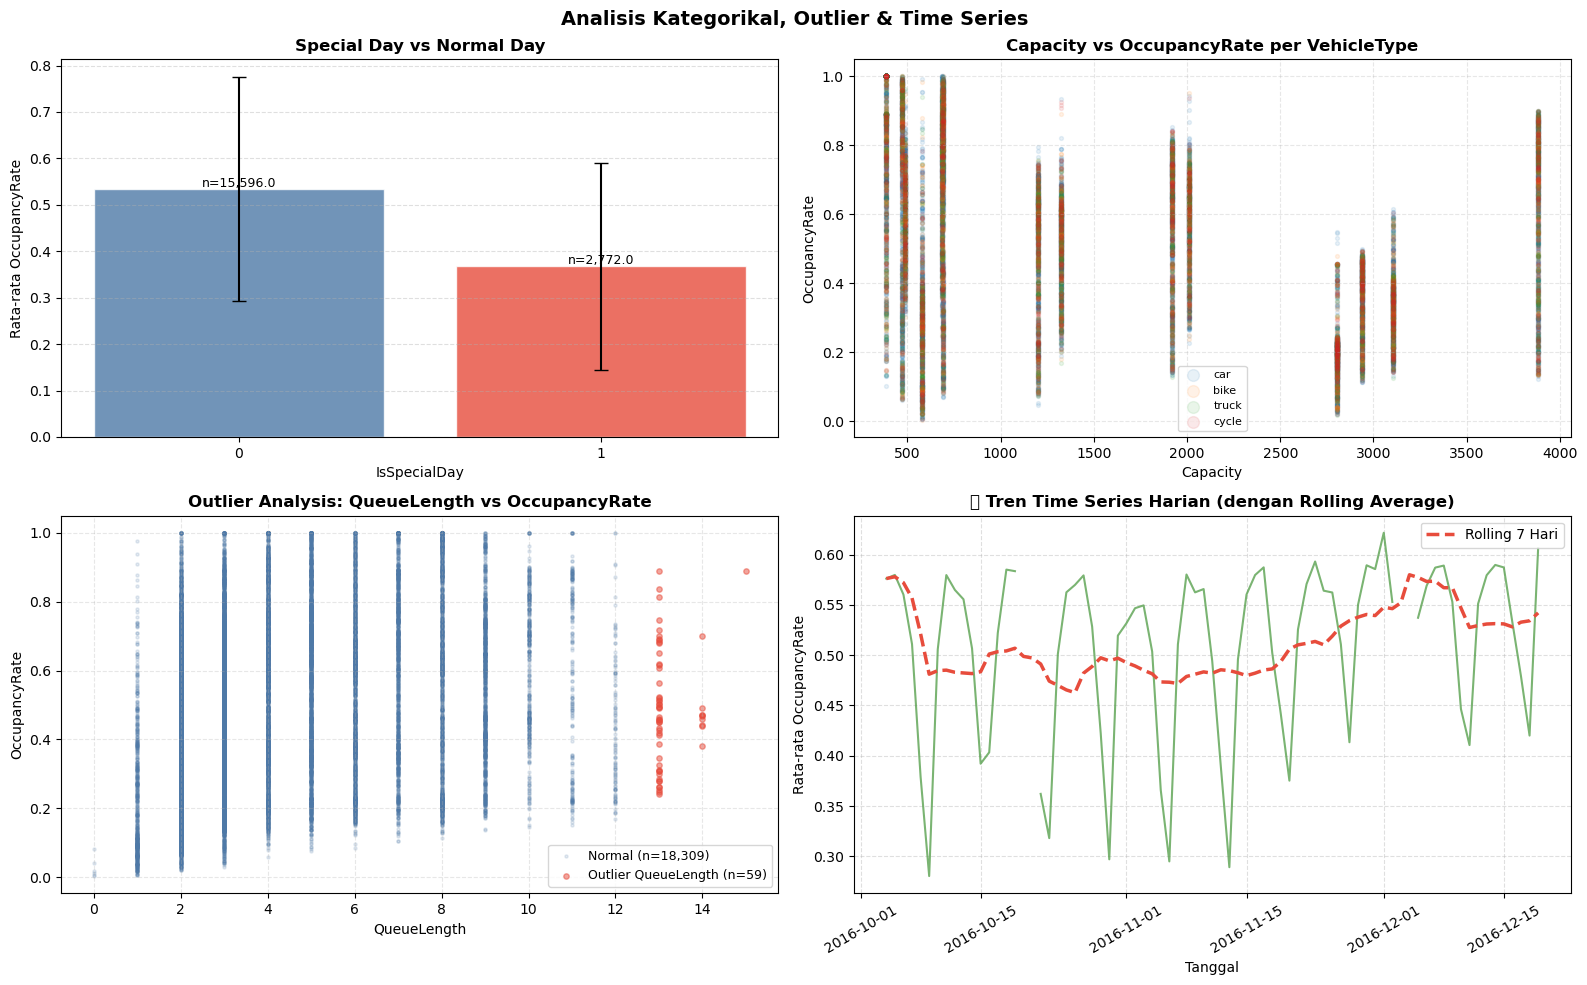


INSIGHT KATEGORIKAL:
  • Hari Spesial meningkatkan OccupancyRate rata-rata 0.167 dibanding hari biasa
  • Jumlah outlier QueueLength (>Q3+1.5*IQR): 59 baris (0.3%)
  • IQR QueueLength: 4.0, batas atas outlier: 12.0


In [10]:
# ─── EDA 4: Analisis Kategorikal & Outlier ───────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

special_agg = df.groupby('IsSpecialDay')['OccupancyRate'].agg(['mean','std','count'])
special_agg['std'] = special_agg['std'].fillna(0)
ax = axes[0, 0]
colors_sd = ['#4e79a7','#e74c3c'][:len(special_agg)]
bars = ax.bar(special_agg.index.astype(str), special_agg['mean'],
              color=colors_sd, alpha=0.8, edgecolor='white')
ax.errorbar(range(len(special_agg)), special_agg['mean'],
            yerr=special_agg['std'], fmt='none', color='black', capsize=5)
ax.set_title('Special Day vs Normal Day', fontweight='bold')
ax.set_xlabel('IsSpecialDay')
ax.set_ylabel('Rata-rata OccupancyRate')
ax.grid(True, linestyle='--', alpha=0.4, axis='y')
for bar, (_, row) in zip(bars, special_agg.iterrows()):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
            f'n={row["count"]:,}', ha='center', fontsize=9)

ax = axes[0, 1]
vt_groups = df['VehicleType'].value_counts().index[:5]
df_vt = df[df['VehicleType'].isin(vt_groups)]
for vt in vt_groups:
    subset = df_vt[df_vt['VehicleType']==vt]
    ax.scatter(subset['Capacity'], subset['OccupancyRate'],
               alpha=0.1, s=8, label=vt)
ax.set_xlabel('Capacity')
ax.set_ylabel('OccupancyRate')
ax.set_title('Capacity vs OccupancyRate per VehicleType', fontweight='bold')
ax.legend(fontsize=8, markerscale=3)
ax.grid(True, linestyle='--', alpha=0.3)

ax = axes[1, 0]
Q1 = df['QueueLength'].quantile(0.25)
Q3 = df['QueueLength'].quantile(0.75)
IQR = Q3 - Q1
upper = Q3 + 1.5 * IQR
outliers = df[df['QueueLength'] > upper]
normal   = df[df['QueueLength'] <= upper]
ax.scatter(normal['QueueLength'], normal['OccupancyRate'],
           alpha=0.15, s=5, color='#4e79a7', label=f'Normal (n={len(normal):,})')
ax.scatter(outliers['QueueLength'], outliers['OccupancyRate'],
           alpha=0.5, s=15, color='#e74c3c', label=f'Outlier QueueLength (n={len(outliers):,})')
ax.set_xlabel('QueueLength')
ax.set_ylabel('OccupancyRate')
ax.set_title('Outlier Analysis: QueueLength vs OccupancyRate', fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, linestyle='--', alpha=0.3)

ax = axes[1, 1]
df['Timestamp'] = pd.to_datetime(df['Timestamp'], errors='coerce')
daily_avg = df.set_index('Timestamp').resample('D')['OccupancyRate'].mean()
if not daily_avg.empty:
    ax.plot(daily_avg.index, daily_avg.values, color='#59a14f', linewidth=1.5, alpha=0.8)
    rolling7 = daily_avg.rolling(7, min_periods=1).mean()
    ax.plot(rolling7.index, rolling7.values, color='#e74c3c', linewidth=2.5,
            linestyle='--', label='Rolling 7 Hari')
ax.set_xlabel('Tanggal')
ax.set_ylabel('Rata-rata OccupancyRate')
ax.set_title('📉 Tren Time Series Harian (dengan Rolling Average)', fontweight='bold')
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4)
ax.tick_params(axis='x', rotation=30)

plt.suptitle('Analisis Kategorikal, Outlier & Time Series', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nINSIGHT KATEGORIKAL:')
df_is_special_1 = df[df['IsSpecialDay'].astype(str) == '1']
df_is_special_0 = df[df['IsSpecialDay'].astype(str) == '0']
sd_mean = df_is_special_1['OccupancyRate'].mean() if not df_is_special_1.empty else None
nd_mean = df_is_special_0['OccupancyRate'].mean() if not df_is_special_0.empty else None
if sd_mean is not None and nd_mean is not None:
    print(f'  • Hari Spesial meningkatkan OccupancyRate rata-rata {abs(sd_mean-nd_mean):.3f} dibanding hari biasa')
print(f'  • Jumlah outlier QueueLength (>Q3+1.5*IQR): {len(outliers):,} baris ({len(outliers)/len(df)*100:.1f}%)')
print(f'  • IQR QueueLength: {IQR:.1f}, batas atas outlier: {upper:.1f}')


## 3c. Feature Engineering Lanjutan

> Selain fitur waktu dasar, kita tambahkan **fitur-fitur baru** untuk meningkatkan kemampuan prediktif model:
> - **Lag features** — OccupancyRate & QueueLength N-jam sebelumnya (temporal memory)
> - **Rolling statistics** — mean & std bergulir untuk menangkap tren jangka pendek
> - **Interaction features** — kombinasi fitur yang mencerminkan kondisi kompleks
> - **Capacity-based features** — rasio dan kategori ukuran parkir
> - **Crowd pressure index** — indikator gabungan tekanan kepadatan


In [13]:
# ─── Feature Engineering Lanjutan ───────────────────────────────────────────
print('Membuat fitur-fitur lanjutan...')

df = df.sort_values(['SystemCodeNumber', 'Timestamp']).reset_index(drop=True)

# ── A. LAG FEATURES per lokasi parkir ────────────────────────────────────────
for lag in [1, 2, 3]:
    df[f'occ_lag_{lag}h'] = (
        df.groupby('SystemCodeNumber')['OccupancyRate']
          .shift(lag)
    )

for lag in [1, 2]:
    df[f'queue_lag_{lag}h'] = (
        df.groupby('SystemCodeNumber')['QueueLength']
          .shift(lag)
    )

# ── B. ROLLING STATISTICS per lokasi parkir ───────────────────────────────────
for window in [3, 6]:
    df[f'occ_roll_mean_{window}h'] = (
        df.groupby('SystemCodeNumber')['OccupancyRate']
          .transform(lambda x: x.shift(1).rolling(window, min_periods=1).mean())
    )
    df[f'occ_roll_std_{window}h'] = (
        df.groupby('SystemCodeNumber')['OccupancyRate']
          .transform(lambda x: x.shift(1).rolling(window, min_periods=1).std().fillna(0))
    )

# ── C. INTERACTION FEATURES ───────────────────────────────────────────────────
df['queue_pressure']     = df['QueueLength'] / (df['Capacity'] + 1)
df['rush_x_weekend']     = df['is_rush_hour'] * df['is_weekend']
df['remaining_capacity'] = df['Capacity'] - df['Occupancy']
df['occ_rate_squared']   = df['OccupancyRate'] ** 2
df['hour_dow_interaction'] = df['hour'] * 7 + df['dayofweek']

# ── D. CAPACITY-BASED FEATURES ────────────────────────────────────────────────
capacity_q = df['Capacity'].quantile([0.33, 0.67])
def capacity_size(cap):
    if cap <= capacity_q[0.33]: return 'Kecil'
    elif cap <= capacity_q[0.67]: return 'Sedang'
    else: return 'Besar'

df['capacity_category'] = df['Capacity'].apply(capacity_size)
df['log_capacity']    = np.log1p(df['Capacity'])
df['log_queue_length'] = np.log1p(df['QueueLength'])

# ── E. CROWD PRESSURE INDEX ───────────────────────────────────────────────────
max_q_pressure = df['queue_pressure'].max()
df['crowd_pressure_index'] = (
    0.7 * df['OccupancyRate'] +
    0.3 * (df['queue_pressure'] / (max_q_pressure + 1e-9))
)

# ── F. TIME OF DAY CATEGORY ───────────────────────────────────────────────────
def time_of_day(hour):
    if 0 <= hour < 6:  return 'Dini_Hari'
    elif 6 <= hour < 12: return 'Pagi'
    elif 12 <= hour < 17: return 'Siang'
    elif 17 <= hour < 21: return 'Sore'
    else: return 'Malam'

df['time_of_day'] = df['hour'].apply(time_of_day)

# ── Ringkasan ─────────────────────────────────────────────────────────────────
new_features = [
    'occ_lag_1h', 'occ_lag_2h', 'occ_lag_3h',
    'queue_lag_1h', 'queue_lag_2h',
    'occ_roll_mean_3h', 'occ_roll_std_3h',
    'occ_roll_mean_6h', 'occ_roll_std_6h',
    'queue_pressure', 'rush_x_weekend', 'remaining_capacity',
    'occ_rate_squared', 'hour_dow_interaction',
    'log_capacity', 'log_queue_length',
    'crowd_pressure_index'
]

nan_counts = df[new_features].isnull().sum()
print('\nFitur Baru yang Ditambahkan:')
for f in new_features:
    nan_pct = nan_counts[f]/len(df)*100
    print(f'  {f:<30} NaN: {nan_counts[f]:,} ({nan_pct:.1f}%)')

print(f'\n  capacity_category  (kategorikal: Kecil/Sedang/Besar)')
print(f'  time_of_day         (kategorikal: Dini_Hari/Pagi/Siang/Sore/Malam)')
print(f'\n Shape dataset setelah feature engineering: {df.shape}')


Membuat fitur-fitur lanjutan...

Fitur Baru yang Ditambahkan:
  occ_lag_1h                     NaN: 14 (0.1%)
  occ_lag_2h                     NaN: 28 (0.2%)
  occ_lag_3h                     NaN: 42 (0.2%)
  queue_lag_1h                   NaN: 14 (0.1%)
  queue_lag_2h                   NaN: 28 (0.2%)
  occ_roll_mean_3h               NaN: 14 (0.1%)
  occ_roll_std_3h                NaN: 0 (0.0%)
  occ_roll_mean_6h               NaN: 14 (0.1%)
  occ_roll_std_6h                NaN: 0 (0.0%)
  queue_pressure                 NaN: 0 (0.0%)
  rush_x_weekend                 NaN: 0 (0.0%)
  remaining_capacity             NaN: 0 (0.0%)
  occ_rate_squared               NaN: 0 (0.0%)
  hour_dow_interaction           NaN: 0 (0.0%)
  log_capacity                   NaN: 0 (0.0%)
  log_queue_length               NaN: 0 (0.0%)
  crowd_pressure_index           NaN: 0 (0.0%)

  capacity_category  (kategorikal: Kecil/Sedang/Besar)
  time_of_day         (kategorikal: Dini_Hari/Pagi/Siang/Sore/Malam)

 Shape

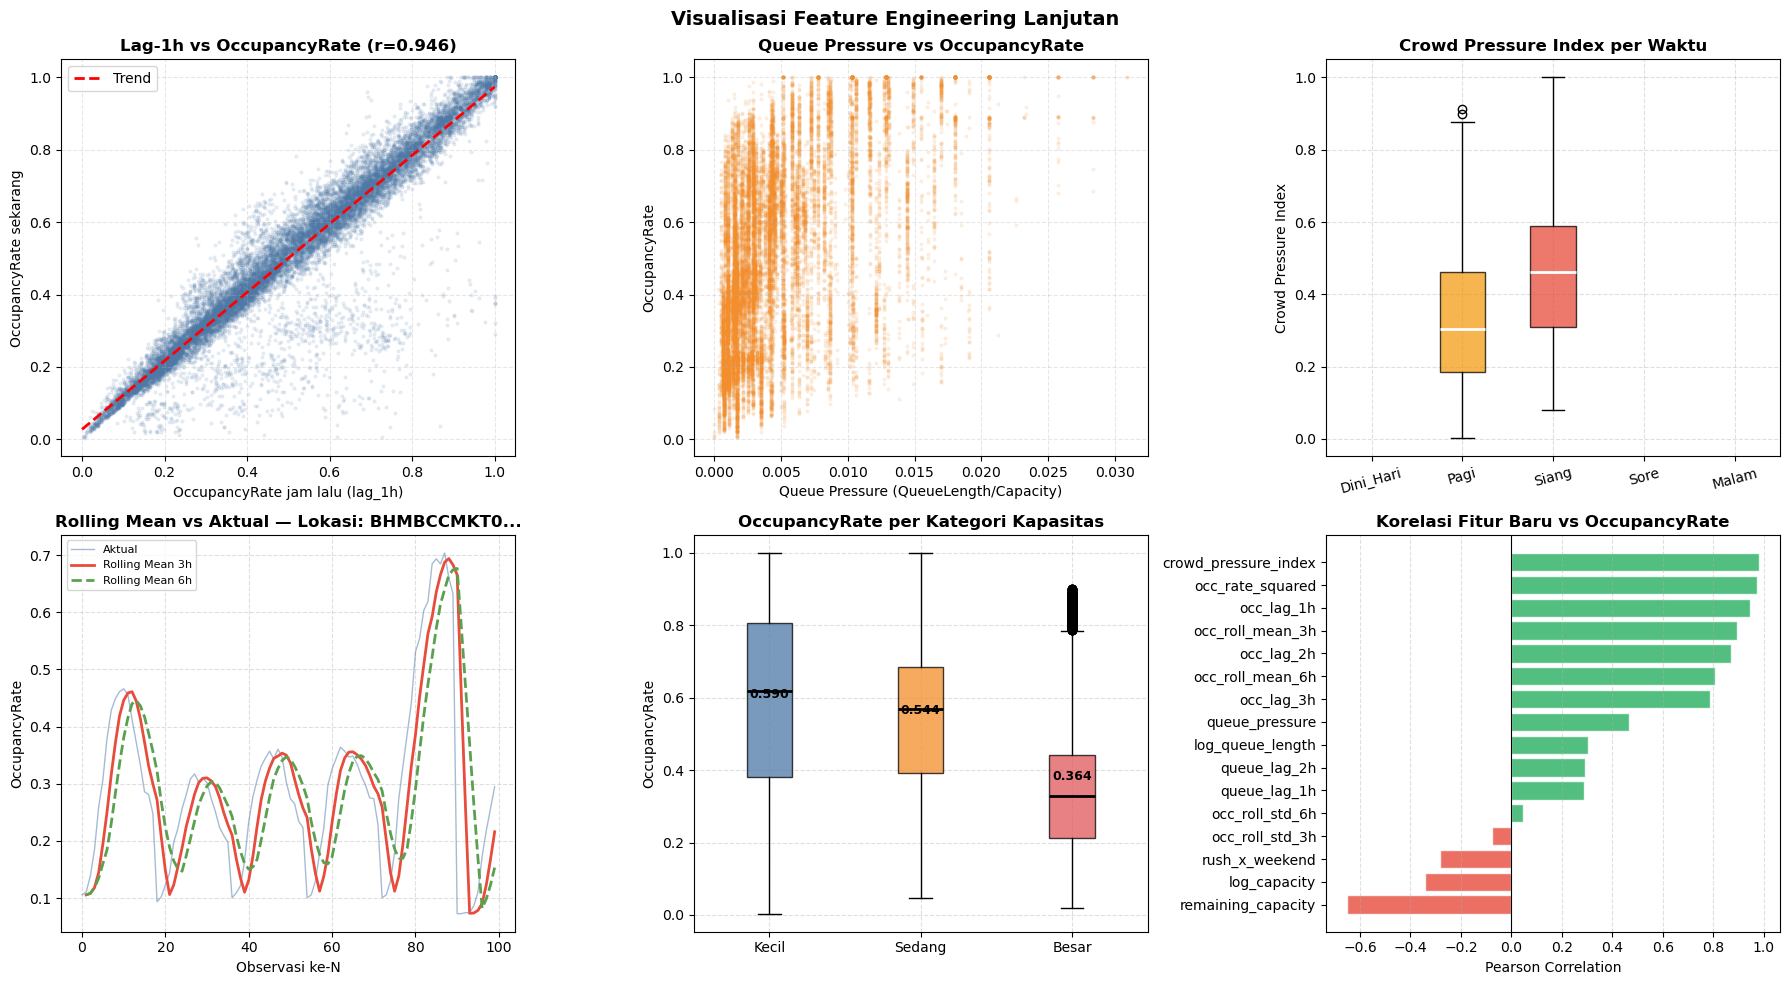


INSIGHT FEATURE ENGINEERING:
  • occ_lag_1h memiliki korelasi 0.946 dengan OccupancyRate → fitur temporal sangat kuat
  • queue_pressure berkorelasi 0.466 dengan OccupancyRate
  • Fitur lag & rolling diharapkan meningkatkan akurasi model karena menangkap memori temporal
  • NaN dari lag features (14 baris) akan diisi median training set sebelum fit model


In [14]:
# ─── Visualisasi Fitur Baru ──────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

ax = axes[0, 0]
lag_data = df[['occ_lag_1h','OccupancyRate']].dropna()
ax.scatter(lag_data['occ_lag_1h'], lag_data['OccupancyRate'],
           alpha=0.1, s=4, color='#4e79a7')
z = np.polyfit(lag_data['occ_lag_1h'], lag_data['OccupancyRate'], 1)
p = np.poly1d(z)
x_line = np.linspace(0, 1, 100)
ax.plot(x_line, p(x_line), 'r--', linewidth=2, label=f'Trend')
corr_lag = lag_data.corr().iloc[0,1]
ax.set_title(f'Lag-1h vs OccupancyRate (r={corr_lag:.3f})', fontweight='bold')
ax.set_xlabel('OccupancyRate jam lalu (lag_1h)')
ax.set_ylabel('OccupancyRate sekarang')
ax.legend(); ax.grid(True, linestyle='--', alpha=0.3)

ax = axes[0, 1]
ax.scatter(df['queue_pressure'], df['OccupancyRate'],
           alpha=0.1, s=4, color='#f28e2b')
ax.set_title('Queue Pressure vs OccupancyRate', fontweight='bold')
ax.set_xlabel('Queue Pressure (QueueLength/Capacity)')
ax.set_ylabel('OccupancyRate')
ax.grid(True, linestyle='--', alpha=0.3)

ax = axes[0, 2]
tod_order = ['Dini_Hari','Pagi','Siang','Sore','Malam']
tod_colors = ['#2c3e50','#f39c12','#e74c3c','#8e44ad','#2980b9']
tod_data = [df[df['time_of_day']==t]['crowd_pressure_index'].values for t in tod_order]
bp = ax.boxplot(tod_data, labels=tod_order, patch_artist=True,
                medianprops=dict(color='white', linewidth=2))
for patch, color in zip(bp['boxes'], tod_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
ax.set_title('Crowd Pressure Index per Waktu', fontweight='bold')
ax.set_ylabel('Crowd Pressure Index')
ax.tick_params(axis='x', rotation=15)
ax.grid(True, linestyle='--', alpha=0.4)

ax = axes[1, 0]
sample_loc = df['SystemCodeNumber'].value_counts().index[0]
df_loc = df[df['SystemCodeNumber']==sample_loc].sort_values('Timestamp').head(100)
ax.plot(range(len(df_loc)), df_loc['OccupancyRate'], alpha=0.5,
        color='#4e79a7', linewidth=1, label='Aktual')
ax.plot(range(len(df_loc)), df_loc['occ_roll_mean_3h'],
        color='#e74c3c', linewidth=2, label='Rolling Mean 3h')
ax.plot(range(len(df_loc)), df_loc['occ_roll_mean_6h'],
        color='#59a14f', linewidth=2, linestyle='--', label='Rolling Mean 6h')
ax.set_title(f'Rolling Mean vs Aktual — Lokasi: {sample_loc[:10]}...', fontweight='bold')
ax.set_xlabel('Observasi ke-N')
ax.set_ylabel('OccupancyRate')
ax.legend(fontsize=8); ax.grid(True, linestyle='--', alpha=0.4)

ax = axes[1, 1]
cap_order = ['Kecil','Sedang','Besar']
cap_colors = ['#4e79a7','#f28e2b','#e15759']
cap_data = [df[df['capacity_category']==c]['OccupancyRate'].values for c in cap_order]
bp2 = ax.boxplot(cap_data, labels=cap_order, patch_artist=True,
                 medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp2['boxes'], cap_colors):
    patch.set_facecolor(color); patch.set_alpha(0.75)
ax.set_title('OccupancyRate per Kategori Kapasitas', fontweight='bold')
ax.set_ylabel('OccupancyRate')
ax.grid(True, linestyle='--', alpha=0.4)
cap_means = [df[df['capacity_category']==c]['OccupancyRate'].mean() for c in cap_order]
for i, mean in enumerate(cap_means):
    ax.text(i+1, mean+0.01, f'{mean:.3f}', ha='center', fontsize=9, fontweight='bold')

ax = axes[1, 2]
numeric_new = [f for f in new_features if f in df.columns and df[f].dtype in ['float64','int64']]
corr_new = df[numeric_new + ['OccupancyRate']].dropna().corr()['OccupancyRate'].drop('OccupancyRate')
corr_new_sorted = corr_new.sort_values()
colors_corr = ['#e74c3c' if v < 0 else '#27ae60' for v in corr_new_sorted]
ax.barh(corr_new_sorted.index, corr_new_sorted.values, color=colors_corr, alpha=0.8, edgecolor='white')
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Korelasi Fitur Baru vs OccupancyRate', fontweight='bold')
ax.set_xlabel('Pearson Correlation')
ax.grid(True, linestyle='--', alpha=0.4, axis='x')

plt.suptitle('Visualisasi Feature Engineering Lanjutan', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nINSIGHT FEATURE ENGINEERING:')
lag1_corr = df[['occ_lag_1h','OccupancyRate']].dropna().corr().iloc[0,1]
print(f'  • occ_lag_1h memiliki korelasi {lag1_corr:.3f} dengan OccupancyRate → fitur temporal sangat kuat')
queue_corr = df[['queue_pressure','OccupancyRate']].corr().iloc[0,1]
print(f'  • queue_pressure berkorelasi {queue_corr:.3f} dengan OccupancyRate')
print(f'  • Fitur lag & rolling diharapkan meningkatkan akurasi model karena menangkap memori temporal')
nan_lag = df['occ_lag_1h'].isnull().sum()
print(f'  • NaN dari lag features ({nan_lag:,} baris) akan diisi median training set sebelum fit model')


## 4. Clustering Geografis (K-Means pada Latitude & Longitude)

> **Tujuan:** Mengelompokkan lokasi parkir berdasarkan posisi geografisnya.  
> Elbow Method digunakan untuk menemukan jumlah zona (K) yang paling optimal.

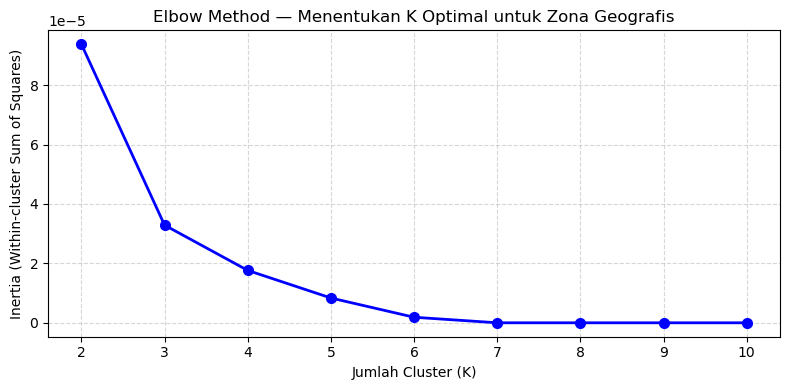

Pilih nilai K di "siku" grafik di atas, lalu isi variabel K_OPTIMAL di bawah.


In [15]:
# Ambil koordinat unik per lokasi agar clustering tidak bias oleh frekuensi data
coords = df[['Latitude', 'Longitude']].drop_duplicates().values
scaler_geo = StandardScaler()
coords_scaled = scaler_geo.fit_transform(coords)

# Elbow Method: coba K = 2 sampai 10
inertia = []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(coords_scaled)
    inertia.append(km.inertia_)

# Plot Elbow
plt.figure(figsize=(8, 4))
plt.plot(K_range, inertia, 'bo-', linewidth=2, markersize=7)
plt.xlabel('Jumlah Cluster (K)')
plt.ylabel('Inertia (Within-cluster Sum of Squares)')
plt.title('Elbow Method — Menentukan K Optimal untuk Zona Geografis')
plt.xticks(K_range)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print('Pilih nilai K di "siku" grafik di atas, lalu isi variabel K_OPTIMAL di bawah.')

In [16]:
# ============================================================
# GANTI nilai K_OPTIMAL sesuai hasil Elbow di atas
# ============================================================
K_OPTIMAL = 3

# Fit K-Means pada SEMUA baris (bukan hanya unik)
coords_all        = df[['Latitude', 'Longitude']].values
coords_all_scaled = scaler_geo.transform(coords_all)

kmeans = KMeans(n_clusters=K_OPTIMAL, random_state=42, n_init=10)
df['Zona'] = kmeans.fit_predict(coords_all_scaled)

print(f'K-Means selesai dengan K={K_OPTIMAL}')
print(f'\nDistribusi baris per zona:')
print(df['Zona'].value_counts().sort_index())

K-Means selesai dengan K=3

Distribusi baris per zona:
Zona
0     3936
1     1312
2    13120
Name: count, dtype: int64


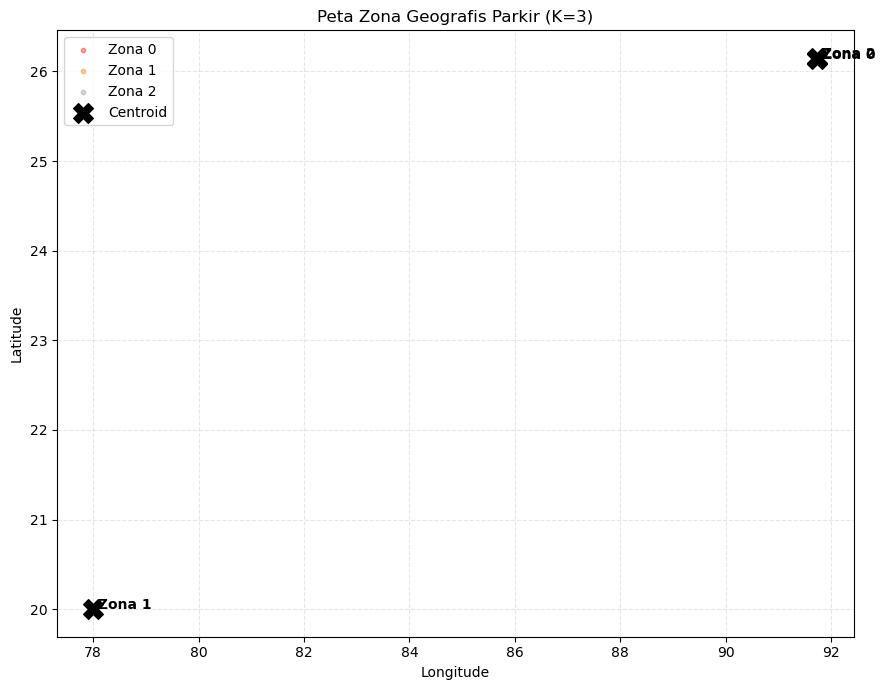

In [17]:
# Visualisasi zona geografis
cmap_zona = plt.cm.get_cmap('Set1', K_OPTIMAL)

plt.figure(figsize=(9, 7))
for z in sorted(df['Zona'].unique()):
    subset = df[df['Zona'] == z]
    plt.scatter(
        subset['Longitude'], subset['Latitude'],
        s=10, alpha=0.4, color=cmap_zona(z), label=f'Zona {z}'
    )

# Plot centroid
centroids = scaler_geo.inverse_transform(kmeans.cluster_centers_)
plt.scatter(
    centroids[:, 1], centroids[:, 0],
    s=200, c='black', marker='X', zorder=5, label='Centroid'
)
for i, (lat, lon) in enumerate(centroids):
    plt.annotate(f' Zona {i}', (lon, lat), fontsize=10, fontweight='bold')

plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title(f'Peta Zona Geografis Parkir (K={K_OPTIMAL})')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

## 5. Labeling Kepadatan per Zona

> Rata-rata `OccupancyRate` per zona dihitung, lalu zona diberi label:
> -  **Sepi** → zona dengan rata-rata OccupancyRate terendah
> -  **Sedang** → zona dengan rata-rata OccupancyRate menengah
> -  **Padat** → zona dengan rata-rata OccupancyRate tertinggi

In [18]:
split_idx = int(len(df) * 0.8)
df_train_only = df.iloc[:split_idx]

q33 = df_train_only['OccupancyRate'].quantile(0.33)
q66 = df_train_only['OccupancyRate'].quantile(0.66)

print(f'Threshold → Sepi: <{q33:.2f} | Sedang: {q33:.2f}–{q66:.2f} | Padat: >{q66:.2f}')

def label_kepadatan(rate):
    if rate < q33:
        return 'Sepi'
    elif rate < q66:
        return 'Sedang'
    else:
        return 'Padat'

df['LabelKepadatan'] = df['OccupancyRate'].apply(label_kepadatan)

print(df['LabelKepadatan'].value_counts())

Threshold → Sepi: <0.38 | Sedang: 0.38–0.66 | Padat: >0.66
LabelKepadatan
Sedang    6415
Sepi      6337
Padat     5616
Name: count, dtype: int64


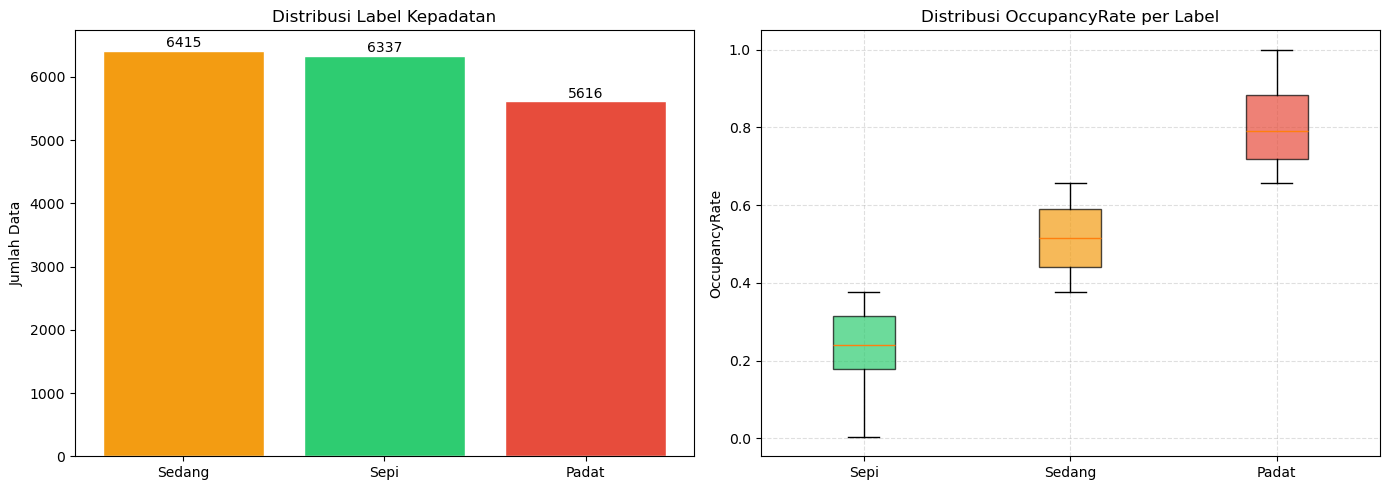

In [19]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Fallback aman jika cell sebelumnya belum dijalankan
if 'LabelKepadatan' not in df.columns:
    q33 = df['OccupancyRate'].quantile(0.33)
    q66 = df['OccupancyRate'].quantile(0.66)
    df['LabelKepadatan'] = df['OccupancyRate'].apply(lambda r: 'Sepi' if r < q33 else ('Sedang' if r < q66 else 'Padat'))

# Bar chart distribusi label
label_counts = df['LabelKepadatan'].value_counts()
colors_label = {'Sepi': '#2ecc71', 'Sedang': '#f39c12', 'Padat': '#e74c3c'}
bar_colors = [colors_label.get(l, 'gray') for l in label_counts.index]
axes[0].bar(label_counts.index, label_counts.values, color=bar_colors, edgecolor='white')
axes[0].set_title('Distribusi Label Kepadatan', fontsize=12)
axes[0].set_ylabel('Jumlah Data')
for i, v in enumerate(label_counts.values):
    axes[0].text(i, v + 50, str(v), ha='center', fontsize=10)

# Box plot OccupancyRate per label
order = [l for l in ['Sepi', 'Sedang', 'Padat'] if l in df['LabelKepadatan'].unique()]
data_box = [df[df['LabelKepadatan'] == l]['OccupancyRate'].values for l in order]
if len(order) > 0:
    bp = axes[1].boxplot(data_box, labels=order, patch_artist=True, notch=False)
    for patch, lbl in zip(bp['boxes'], order):
        patch.set_facecolor(colors_label.get(lbl, 'gray'))
        patch.set_alpha(0.7)
axes[1].set_title('Distribusi OccupancyRate per Label', fontsize=12)
axes[1].set_ylabel('OccupancyRate')
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()


## 6. Persiapan Fitur & Time-Based Split

In [20]:
# Fitur untuk klasifikasi — TERMASUK fitur engineering lanjutan
# Lag & rolling features diisi median TRAINING set untuk menghindari leakage

lag_roll_cols = [
    'occ_lag_1h', 'occ_lag_2h', 'occ_lag_3h',
    'queue_lag_1h', 'queue_lag_2h',
    'occ_roll_mean_3h', 'occ_roll_std_3h',
    'occ_roll_mean_6h', 'occ_roll_std_6h',
]

num_cols = [
    # Fitur original
    'Latitude', 'Longitude', 'Capacity', 'QueueLength',
    'hour', 'dayofweek', 'month', 'is_weekend',
    'hour_sin', 'hour_cos', 'is_rush_hour',
    # Fitur baru — numerik (dibuang fitur leakage: remaining_capacity, occ_rate_squared, crowd_pressure_index)
    'queue_pressure', 'rush_x_weekend', 'hour_dow_interaction',
    'log_capacity', 'log_queue_length',
] + lag_roll_cols

cat_cols = [
    'VehicleType', 'TrafficConditionNearby', 'IsSpecialDay',
    'capacity_category', 'time_of_day'   # fitur kategorikal baru
]

X = df[num_cols + cat_cols].copy()

# Encode label
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y     = df['LabelKepadatan']
y_enc = le.fit_transform(y)
print('Kelas label:', le.classes_)

# Time-based split 80/20
split_idx  = int(len(df) * 0.8)
X_train, X_test = X.iloc[:split_idx].copy(), X.iloc[split_idx:].copy()
y_train, y_test = y_enc[:split_idx], y_enc[split_idx:]

# ── Isi NaN lag/rolling dengan MEDIAN TRAINING SET (anti-leakage) ─────────────
lag_medians = {}
for col in lag_roll_cols:
    med = X_train[col].median()
    lag_medians[col] = med
    X_train[col] = X_train[col].fillna(med)
    X_test[col]  = X_test[col].fillna(med)

print('\n=== TIME-BASED SPLIT ===')
print(f'Total    : {len(df):,}')
print(f'Training : {len(X_train):,} ({len(X_train)/len(df)*100:.0f}%)')
print(f'Testing  : {len(X_test):,}  ({len(X_test)/len(df)*100:.0f}%)')
print(f'\nPeriode training : {df["Timestamp"].iloc[0]} → {df["Timestamp"].iloc[split_idx-1]}')
print(f'Periode testing  : {df["Timestamp"].iloc[split_idx]} → {df["Timestamp"].iloc[-1]}')
print(f'\nTotal fitur      : {len(num_cols + cat_cols)} (numerik={len(num_cols)}, kategorikal={len(cat_cols)})')
print(f'NaN tersisa di X_train: {X_train.isnull().sum().sum()}')
print(f'NaN tersisa di X_test : {X_test.isnull().sum().sum()}')


Kelas label: ['Padat' 'Sedang' 'Sepi']

=== TIME-BASED SPLIT ===
Total    : 18,368
Training : 14,694 (80%)
Testing  : 3,674  (20%)

Periode training : 2016-10-04 07:59:00 → 2016-10-18 12:27:00
Periode testing  : 2016-10-18 13:01:00 → 2016-12-19 16:30:00

Total fitur      : 30 (numerik=25, kategorikal=5)
NaN tersisa di X_train: 0
NaN tersisa di X_test : 0


## 7. Membangun & Melatih Model Klasifikasi

| Model | Keterangan |
|---|---|
| **SVM (SVC)** | Support Vector Machine untuk klasifikasi, kernel RBF |
| **XGBoost** | Gradient Boosting berbasis pohon keputusan |
| **Ridge Classifier** | Regresi Ridge yang diadaptasi untuk klasifikasi |
| **Naive Bayes** | Probabilistik Gaussian, cepat & interpretable |
| **KNN** | K-Nearest Neighbors, berbasis jarak antar sampel |


In [21]:
from xgboost import XGBClassifier
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Preprocessor
preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), num_cols),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), cat_cols)
])

# Definisi model
models = {
    'SVM (SVC)'       : SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42),
    'XGBoost'         : XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=5,
                                      use_label_encoder=False, eval_metric='mlogloss',
                                      random_state=42),
    'Ridge Classifier': RidgeClassifier(alpha=1.0),
    'Naive Bayes'     : GaussianNB(),
    'KNN'             : KNeighborsClassifier(n_neighbors=11, metric='euclidean', n_jobs=-1)
}

results     = {}
pipelines   = {}
predictions = {}

for name, model in models.items():
    print(f'Training: {name}...')
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    results[name]     = {'Accuracy': acc}
    pipelines[name]   = pipe
    predictions[name] = y_pred

    print(f'Accuracy = {acc:.4f}')

print('\nSemua model selesai dilatih')


Training: SVM (SVC)...
Accuracy = 0.9094
Training: XGBoost...
Accuracy = 0.9540
Training: Ridge Classifier...
Accuracy = 0.7175
Training: Naive Bayes...
Accuracy = 0.7746
Training: KNN...
Accuracy = 0.8070

Semua model selesai dilatih


## 8. Evaluasi Model

In [22]:
eval_rows = []
label_names = le.classes_

for name, y_pred in predictions.items():
    from sklearn.metrics import precision_score, recall_score, f1_score
    row = {
        'Model'    : name,
        'Accuracy' : round(accuracy_score(y_test, y_pred), 4),
        'Precision': round(precision_score(y_test, y_pred, average='weighted', zero_division=0), 4),
        'Recall'   : round(recall_score(y_test, y_pred, average='weighted', zero_division=0), 4),
        'F1-Score' : round(f1_score(y_test, y_pred, average='weighted', zero_division=0), 4)
    }
    eval_rows.append(row)

eval_df = pd.DataFrame(eval_rows).set_index('Model')
best_model_name = eval_df['Accuracy'].idxmax()

print(f'Model Terbaik: {best_model_name}')
print('='*60)
eval_df

Model Terbaik: XGBoost


,Accuracy,Precision,Recall,F1-Score
Model,,,,
SVM (SVC),0.9094,0.9139,0.9094,0.9095
XGBoost,0.9540,0.9544,0.9540,0.9541
Ridge Classifier,0.7175,0.7178,0.7175,0.7125
Naive Bayes,0.7746,0.7768,0.7746,0.7711
KNN,0.8070,0.8203,0.8070,0.8083


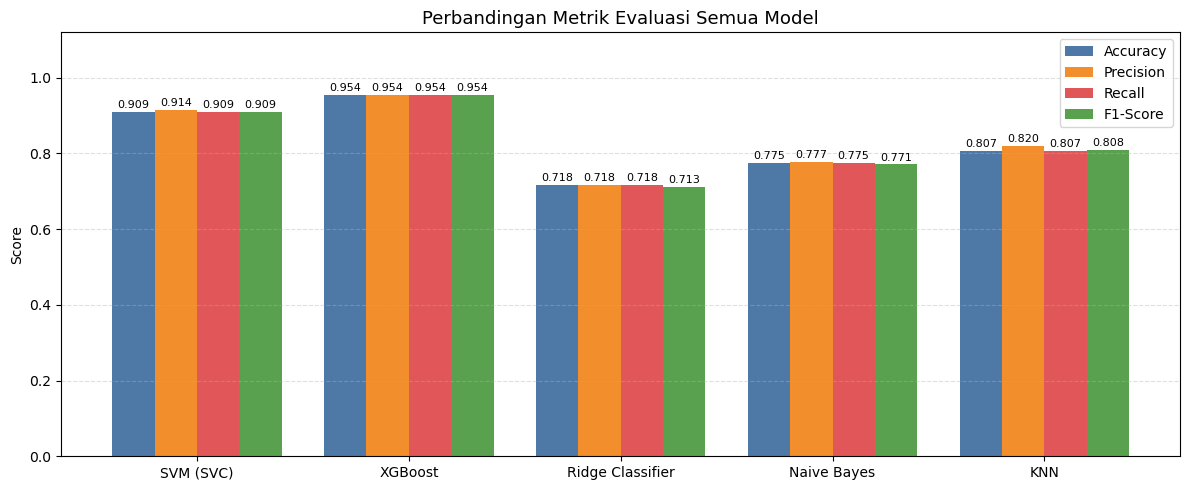

In [23]:
# Grafik perbandingan metrik
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
x = np.arange(len(eval_df))
width = 0.2
colors_bar = ['#4e79a7', '#f28e2b', '#e15759', '#59a14f']

fig, ax = plt.subplots(figsize=(12, 5))
for i, (metric, color) in enumerate(zip(metrics, colors_bar)):
    bars = ax.bar(x + i*width, eval_df[metric], width, label=metric, color=color)
    for bar in bars:
        ax.text(
            bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.005,
            f'{bar.get_height():.3f}', ha='center', va='bottom', fontsize=8
        )

ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(eval_df.index, fontsize=10)
ax.set_ylim(0, 1.12)
ax.set_ylabel('Score')
ax.set_title('Perbandingan Metrik Evaluasi Semua Model', fontsize=13)
ax.legend()
ax.grid(True, linestyle='--', alpha=0.4, axis='y')
plt.tight_layout()
plt.show()

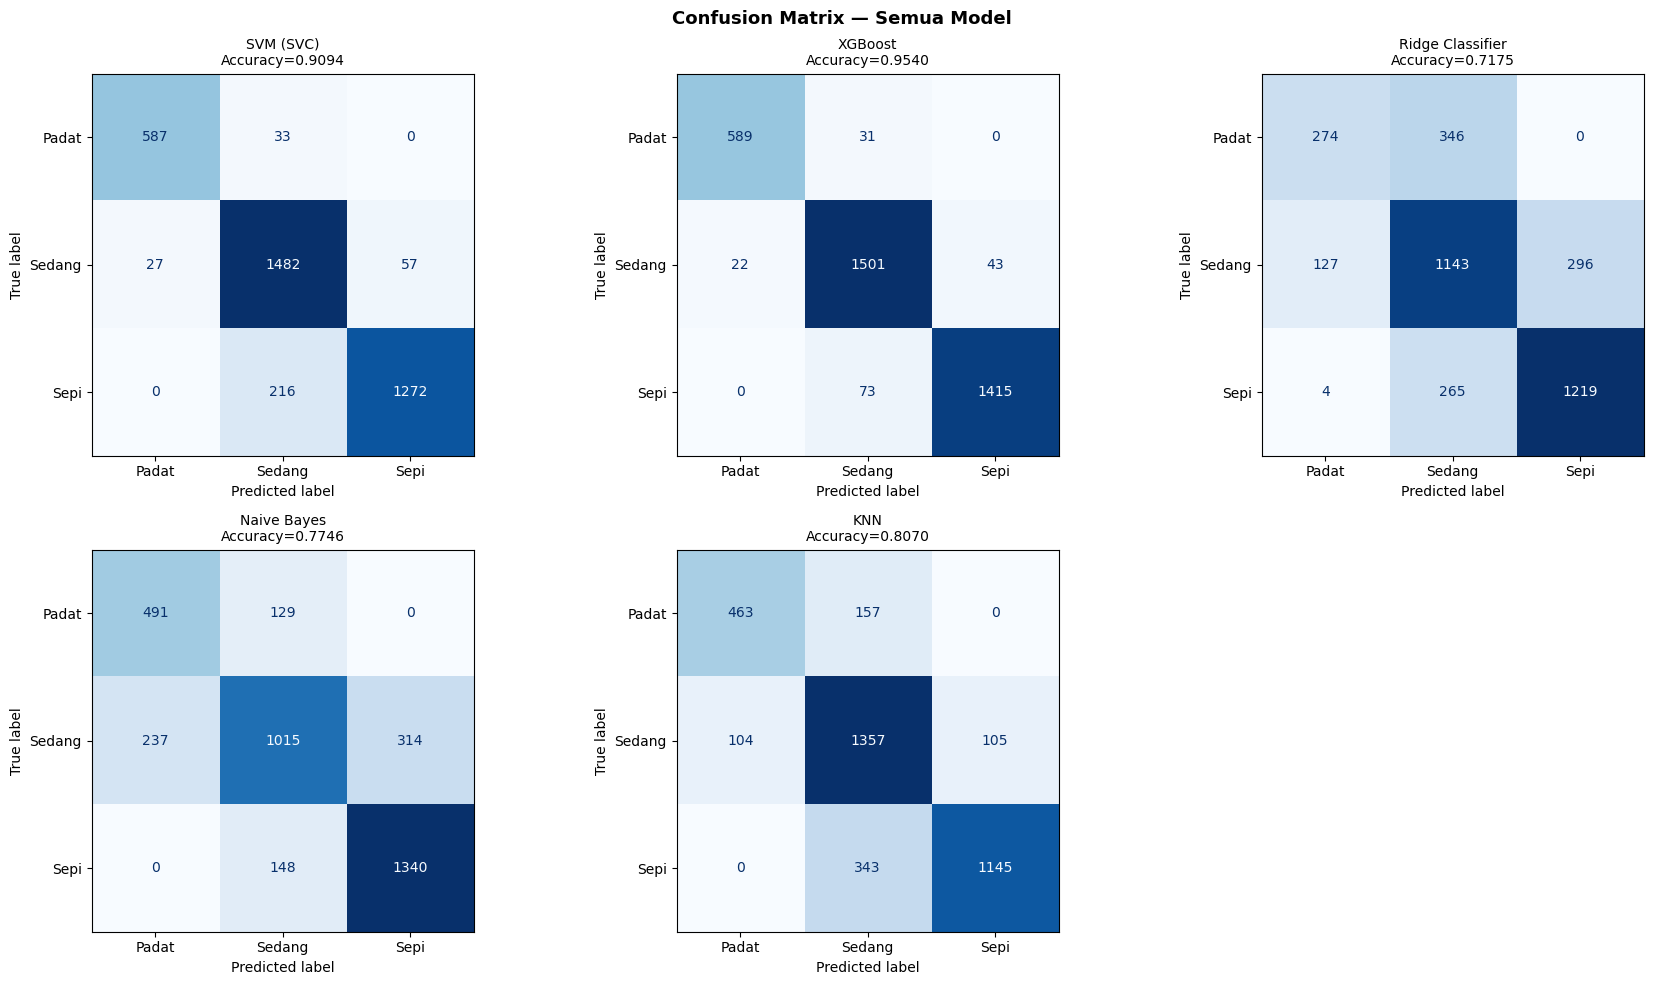

In [24]:
# Confusion Matrix semua model (2 baris × 3 kolom untuk 5 model)
n_models = len(predictions)
ncols = 3
nrows = (n_models + ncols - 1) // ncols  # ceiling division

fig, axes = plt.subplots(nrows, ncols, figsize=(18, 5 * nrows))
axes_flat = axes.flatten() if nrows > 1 else axes
display_labels = le.classes_

for ax, (name, y_pred) in zip(axes_flat, predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    acc_val = results[name]['Accuracy']
    ax.set_title(f'{name}\nAccuracy={acc_val:.4f}', fontsize=10)

# Sembunyikan axes kosong jika ada
for ax in axes_flat[n_models:]:
    ax.set_visible(False)

plt.suptitle('Confusion Matrix — Semua Model', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


In [25]:
# Classification report model terbaik
print(f'=== Classification Report: {best_model_name} ===')
print(classification_report(
    y_test,
    predictions[best_model_name],
    target_names=le.classes_
))

=== Classification Report: XGBoost ===
              precision    recall  f1-score   support

       Padat       0.96      0.95      0.96       620
      Sedang       0.94      0.96      0.95      1566
        Sepi       0.97      0.95      0.96      1488

    accuracy                           0.95      3674
   macro avg       0.96      0.95      0.95      3674
weighted avg       0.95      0.95      0.95      3674



ANALISIS NAIVE BAYES vs KNN

🔹 Naive Bayes
              precision    recall  f1-score   support

       Padat       0.67      0.79      0.73       620
      Sedang       0.79      0.65      0.71      1566
        Sepi       0.81      0.90      0.85      1488

    accuracy                           0.77      3674
   macro avg       0.76      0.78      0.76      3674
weighted avg       0.78      0.77      0.77      3674


🔹 KNN
              precision    recall  f1-score   support

       Padat       0.82      0.75      0.78       620
      Sedang       0.73      0.87      0.79      1566
        Sepi       0.92      0.77      0.84      1488

    accuracy                           0.81      3674
   macro avg       0.82      0.79      0.80      3674
weighted avg       0.82      0.81      0.81      3674


Pengaruh nilai K terhadap akurasi KNN:
  K= 3  →  Accuracy: 0.7964
  K= 5  →  Accuracy: 0.7942
  K= 7  →  Accuracy: 0.7975
  K= 9  →  Accuracy: 0.7978
  K=11  →  Accuracy: 0.8070
  K=15  

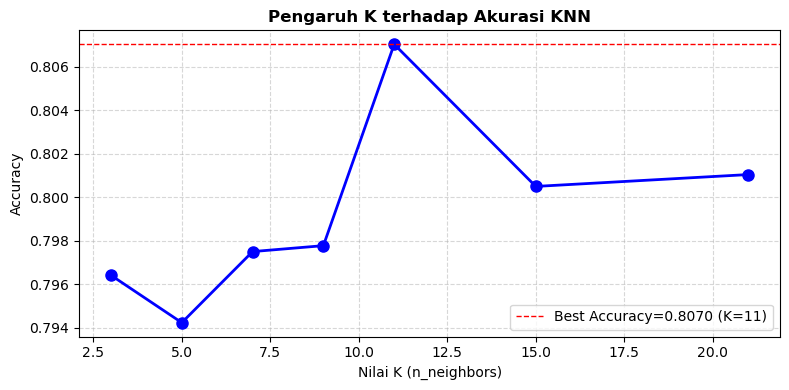

In [26]:
# ─── Analisis Khusus: Naive Bayes & KNN ─────────────────────────────────────
print("=" * 60)
print("ANALISIS NAIVE BAYES vs KNN")
print("=" * 60)

for name in ['Naive Bayes', 'KNN']:
    if name in predictions:
        print(f"\n🔹 {name}")
        print(classification_report(y_test, predictions[name], target_names=le.classes_))

# Eksperimen: pengaruh K pada KNN
print("\nPengaruh nilai K terhadap akurasi KNN:")
k_values = [3, 5, 7, 9, 11, 15, 21]
knn_accs = []

from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

preprocessor_knn = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), num_cols),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), cat_cols)
])

for k in k_values:
    knn_pipe = Pipeline([
        ('preprocessor', preprocessor_knn),
        ('model', KNeighborsClassifier(n_neighbors=k, metric='euclidean', n_jobs=-1))
    ])
    knn_pipe.fit(X_train, y_train)
    acc_k = accuracy_score(y_test, knn_pipe.predict(X_test))
    knn_accs.append(acc_k)
    print(f"  K={k:>2}  →  Accuracy: {acc_k:.4f}")

# Plot pengaruh K
plt.figure(figsize=(8, 4))
plt.plot(k_values, knn_accs, 'bo-', linewidth=2, markersize=8)
plt.axhline(max(knn_accs), color='red', linestyle='--', linewidth=1,
            label=f'Best Accuracy={max(knn_accs):.4f} (K={k_values[knn_accs.index(max(knn_accs))]})')
plt.xlabel('Nilai K (n_neighbors)')
plt.ylabel('Accuracy')
plt.title('Pengaruh K terhadap Akurasi KNN', fontweight='bold')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


## 9. Cross-Validation (TimeSeriesSplit)

> Memberikan estimasi performa yang lebih andal dari satu kali split.

In [27]:
tscv = TimeSeriesSplit(n_splits=5)
cv_summary = []

for name, pipe in pipelines.items():
    print(f'CV: {name}...')
    scores = cross_val_score(pipe, X, y_enc, cv=tscv, scoring='accuracy', n_jobs=1)
    cv_summary.append({
        'Model'       : name,
        'CV Mean Acc' : round(scores.mean(), 4),
        'CV Std'      : round(scores.std(), 4),
        'Min'         : round(scores.min(), 4),
        'Max'         : round(scores.max(), 4)
    })
    print(f'   {scores.mean():.4f} ± {scores.std():.4f}')

cv_df = pd.DataFrame(cv_summary).set_index('Model')
print('\nRingkasan Cross-Validation:')
cv_df

CV: SVM (SVC)...
   0.7310 ± 0.2151
CV: XGBoost...
   0.9317 ± 0.0277
CV: Ridge Classifier...
   0.5283 ± 0.1236
CV: Naive Bayes...
   0.5954 ± 0.1169
CV: KNN...
   0.6935 ± 0.0933

Ringkasan Cross-Validation:


,CV Mean Acc,CV Std,Min,Max
Model,,,,
SVM (SVC),0.7310,0.2151,0.3920,0.9301
XGBoost,0.9317,0.0277,0.8827,0.9566
Ridge Classifier,0.5283,0.1236,0.3113,0.6619
Naive Bayes,0.5954,0.1169,0.4414,0.7762
KNN,0.6935,0.0933,0.5632,0.7929


In [28]:
# Tampilkan detail CV scores per model
print("\n📊 Detail CV Scores per Model:")
print("=" * 55)

tscv_detail = TimeSeriesSplit(n_splits=5)

for name, pipe in pipelines.items():
    scores = cross_val_score(pipe, X, y_enc, cv=tscv_detail, scoring='accuracy', n_jobs=1)
    bar = '█' * int(scores.mean() * 30)
    print(f"  {name:<20} {bar}  {scores.mean():.4f} ± {scores.std():.4f}")



📊 Detail CV Scores per Model:
  SVM (SVC)            █████████████████████  0.7310 ± 0.2151
  XGBoost              ███████████████████████████  0.9317 ± 0.0277
  Ridge Classifier     ███████████████  0.5283 ± 0.1236
  Naive Bayes          █████████████████  0.5954 ± 0.1169
  KNN                  ████████████████████  0.6935 ± 0.0933


## 10. Hyperparameter Tuning

In [41]:
!pip install -q optuna


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [29]:
import optuna
from optuna.samplers import TPESampler
optuna.logging.set_verbosity(optuna.logging.WARNING)

In [31]:
# Preprocessor sementara untuk Optuna (fit sekali)
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
preprocessor_opt = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler())
    ]), num_cols),
    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('ohe', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
    ]), cat_cols)
])
X_train_opt = preprocessor_opt.fit_transform(X_train)
X_test_opt  = preprocessor_opt.transform(X_test)

def objective(trial):
    params = {
        'n_estimators'      : trial.suggest_int('n_estimators', 100, 500),
        'max_depth'         : trial.suggest_int('max_depth', 3, 10),
        'learning_rate'     : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample'         : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree'  : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'min_child_weight'  : trial.suggest_int('min_child_weight', 1, 10),
        'gamma'             : trial.suggest_float('gamma', 0.0, 1.0),
        'reg_alpha'         : trial.suggest_float('reg_alpha', 1e-8, 1.0, log=True),
        'reg_lambda'        : trial.suggest_float('reg_lambda', 1e-8, 1.0, log=True),
        'eval_metric'       : 'mlogloss',
        'random_state'      : 42,
        'use_label_encoder' : False,
    }
    model = XGBClassifier(**params)

    # Pakai TimeSeriesSplit agar konsisten dengan CV utama
    tscv_opt = TimeSeriesSplit(n_splits=3)
    scores = cross_val_score(model, X_train_opt, y_train, cv=tscv_opt, scoring='accuracy', n_jobs=1)
    return scores.mean()

study = optuna.create_study(direction='maximize', sampler=TPESampler(seed=42))
study.optimize(objective, n_trials=50, show_progress_bar=True)

best_params = study.best_params
best_params.update({'eval_metric': 'mlogloss', 'random_state': 42, 'use_label_encoder': False})

print(f'\n Best CV Accuracy : {study.best_value:.4f}')
print(f' Best Params      : {best_params}')


  0%|          | 0/50 [00:00<?, ?it/s]


 Best CV Accuracy : 0.9315
 Best Params      : {'n_estimators': 437, 'max_depth': 8, 'learning_rate': 0.10424537062990079, 'subsample': 0.8189018903465787, 'colsample_bytree': 0.6735444559351283, 'min_child_weight': 2, 'gamma': 0.3296636851205597, 'reg_alpha': 1.4411456187332757e-06, 'reg_lambda': 0.05131218295900824, 'eval_metric': 'mlogloss', 'random_state': 42, 'use_label_encoder': False}


In [33]:
models = {
    'SVM (SVC)'       : SVC(kernel='rbf', C=10, gamma='scale', probability=True, random_state=42),
    'XGBoost'         : XGBClassifier(**best_params),
    'Ridge Classifier': RidgeClassifier(alpha=1.0),
    'Naive Bayes'     : GaussianNB(),
    'KNN'             : KNeighborsClassifier(n_neighbors=11, metric='euclidean', n_jobs=-1)
}


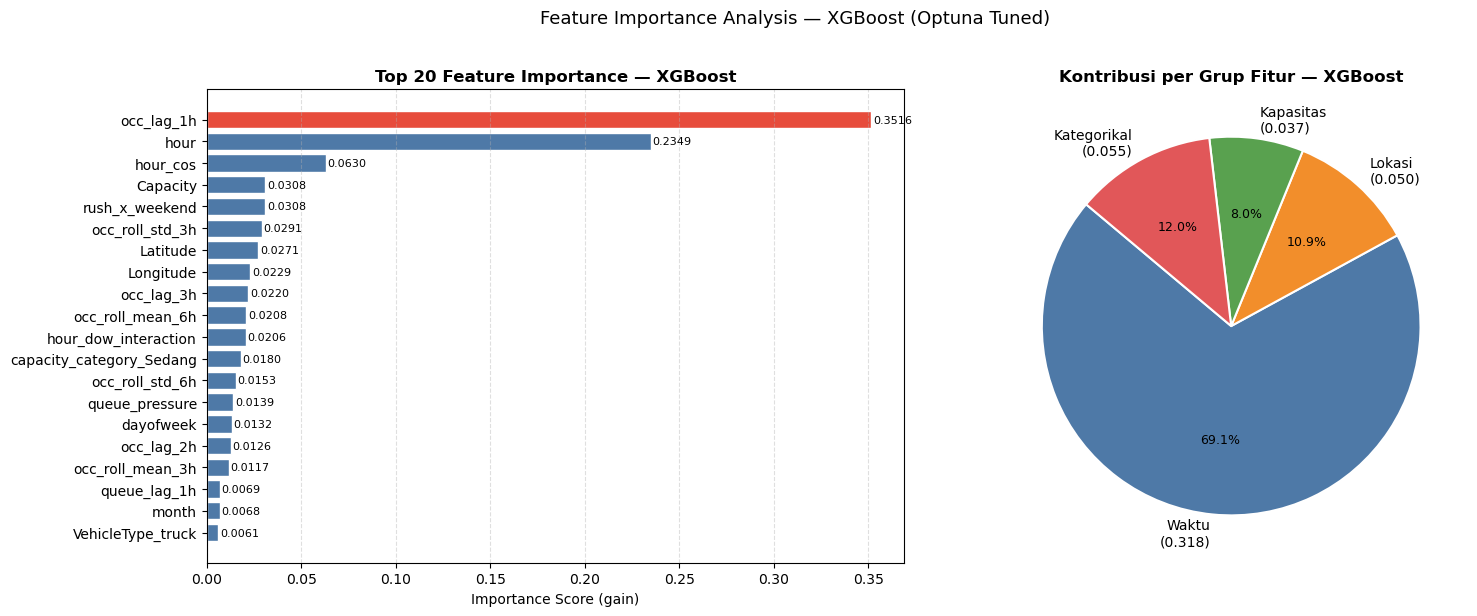


Top 10 Fitur Terpenting:
               Fitur  Importance
1         occ_lag_1h    0.351595
2               hour    0.234895
3           hour_cos    0.062978
4           Capacity    0.030810
5     rush_x_weekend    0.030793
6    occ_roll_std_3h    0.029092
7           Latitude    0.027117
8          Longitude    0.022906
9         occ_lag_3h    0.021981
10  occ_roll_mean_6h    0.020816

Fitur dengan importance = 0 (10 fitur):
['IsSpecialDay_1', 'time_of_day_Pagi', 'capacity_category_Kecil', 'capacity_category_Besar', 'log_queue_length', 'log_capacity', 'is_weekend', 'hour_sin', 'is_rush_hour', 'time_of_day_Siang']


In [36]:
# Ambil XGBoost dari pipeline
xgb_model = pipelines['XGBoost'].named_steps['model']

# Ambil nama fitur setelah preprocessing
ohe_features = pipelines['XGBoost'].named_steps['preprocessor'] \
                .named_transformers_['cat'] \
                .get_feature_names_out(cat_cols).tolist()
all_features = num_cols + ohe_features

# Ambil importance score
importance = xgb_model.feature_importances_

# Urutkan dari terbesar
sorted_idx = np.argsort(importance)[::-1]
top_n      = 20  # tampilkan top 20 fitur

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- Bar chart Top N ---
ax = axes[0]
top_features = [all_features[i] for i in sorted_idx[:top_n]]
top_scores   = importance[sorted_idx[:top_n]]

colors = ['#e74c3c' if s == top_scores.max() else '#4e79a7' for s in top_scores]
bars = ax.barh(top_features[::-1], top_scores[::-1], color=colors[::-1], edgecolor='white')
ax.set_xlabel('Importance Score (gain)')
ax.set_title(f'Top {top_n} Feature Importance — XGBoost', fontsize=12, fontweight='bold')
for bar, score in zip(bars, top_scores[::-1]):
    ax.text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
            f'{score:.4f}', va='center', fontsize=8)
ax.grid(True, linestyle='--', alpha=0.4, axis='x')

# --- Pie chart kontribusi per grup fitur ---
ax2 = axes[1]
grup = {
    'Waktu'      : ['hour', 'dayofweek', 'month', 'is_weekend', 'hour_sin', 'hour_cos', 'is_rush_hour'],
    'Lokasi'     : ['Latitude', 'Longitude'],
    'Kapasitas'  : ['Capacity', 'QueueLength'],
    'Kategorikal': ohe_features,
}

grup_scores = {}
for grup_name, cols in grup.items():
    idx = [i for i, f in enumerate(all_features) if f in cols]
    grup_scores[grup_name] = importance[idx].sum()

pie_labels = [f'{k}\n({v:.3f})' for k, v in grup_scores.items()]
pie_colors = ['#4e79a7', '#f28e2b', '#59a14f', '#e15759']
wedges, texts, autotexts = ax2.pie(
    grup_scores.values(),
    labels=pie_labels,
    colors=pie_colors,
    autopct='%1.1f%%',
    startangle=140,
    wedgeprops={'edgecolor': 'white', 'linewidth': 1.5}
)
for at in autotexts:
    at.set_fontsize(9)
ax2.set_title('Kontribusi per Grup Fitur — XGBoost', fontsize=12, fontweight='bold')

plt.suptitle('Feature Importance Analysis — XGBoost (Optuna Tuned)', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

# --- Tabel ringkasan ---
fi_df = pd.DataFrame({
    'Fitur'      : all_features,
    'Importance' : importance
}).sort_values('Importance', ascending=False).reset_index(drop=True)
fi_df.index += 1

print(f'\nTop 10 Fitur Terpenting:')
print(fi_df.head(10).to_string())
print(f'\nFitur dengan importance = 0 ({(importance == 0).sum()} fitur):')
print(fi_df[fi_df['Importance'] == 0]['Fitur'].tolist())

## 11. Export Model Terbaik untuk Deployment

In [37]:
import json

best_pipeline = pipelines[best_model_name]

# Simpan pipeline model terbaik
joblib.dump(best_pipeline, 'model_parkir.pkl')

# Simpan K-Means & scaler geografis
joblib.dump(kmeans,     'kmeans_geo.pkl')
joblib.dump(scaler_geo, 'scaler_geo.pkl')

# Simpan LabelEncoder
joblib.dump(le, 'label_encoder.pkl')

# Simpan metadata
metadata = {
    'best_model'   : best_model_name,
    'K_optimal'    : int(K_OPTIMAL),
    'q33_threshold': float(q33),
    'q66_threshold': float(q66),
    'label_classes': le.classes_.tolist(),
    'num_cols'     : num_cols,
    'cat_cols'     : cat_cols,
    'vehicle_types': df['VehicleType'].unique().tolist(),
    'traffic_conds': df['TrafficConditionNearby'].unique().tolist(),
    'accuracy_test': round(eval_df.loc[best_model_name, 'Accuracy'], 4)
}

with open('model_metadata.json', 'w') as f:
    json.dump(metadata, f, indent=2)

print('   File yang disimpan:')
print('   model_parkir.pkl      — Pipeline model terbaik')
print('   kmeans_geo.pkl        — Model K-Means zona geografis')
print('   scaler_geo.pkl        — Scaler koordinat')
print('   label_encoder.pkl     — Label encoder kepadatan')
print('   model_metadata.json   — Metadata (konfigurasi & info model)')
print(f'\nModel yang diekspor: {best_model_name}')
print(f'Accuracy test set   : {metadata["accuracy_test"]}')

   File yang disimpan:
   model_parkir.pkl      — Pipeline model terbaik
   kmeans_geo.pkl        — Model K-Means zona geografis
   scaler_geo.pkl        — Scaler koordinat
   label_encoder.pkl     — Label encoder kepadatan
   model_metadata.json   — Metadata (konfigurasi & info model)

Model yang diekspor: XGBoost
Accuracy test set   : 0.954


In [39]:
import os
from IPython.display import FileLink, display

file_list = ['model_parkir.pkl', 'kmeans_geo.pkl', 'scaler_geo.pkl', 'label_encoder.pkl', 'model_metadata.json']

print("Silakan klik link di bawah untuk mendownload file:\n")

for fname in file_list:
    if os.path.exists(fname):
        display(FileLink(fname))
    else:
        print(f"File {fname} tidak ditemukan di direktori.")

print('\nSemua file siap dipakai di Streamlit!')

Silakan klik link di bawah untuk mendownload file:



C:\Users\User\Machine Learning\Matkul_ds\model_parkir.pkl

C:\Users\User\Machine Learning\Matkul_ds\kmeans_geo.pkl

C:\Users\User\Machine Learning\Matkul_ds\scaler_geo.pkl

C:\Users\User\Machine Learning\Matkul_ds\label_encoder.pkl

C:\Users\User\Machine Learning\Matkul_ds\model_metadata.json


Semua file siap dipakai di Streamlit!


---
## Ringkasan

| Tahap | Keterangan |
|---|---|
| Preprocessing | Cleaning, clip Occupancy, feature engineering waktu |
| Clustering | K-Means pada Lat/Long, K ditentukan Elbow Method |
| Labeling | Zona diurutkan by avg OccupancyRate → Sepi/Sedang/Padat |
| Split | Time-based (bukan random) untuk hindari data leakage |
| Model | SVM, XGBoost, Ridge Classifier, Naive Bayes, KNN |
| Evaluasi | Accuracy, Precision, Recall, F1, Confusion Matrix, CV |
| Export | 5 file `.pkl/.json` siap pakai di Streamlit |
